In [74]:
# Isaac Berez
# 17.01.23
import sys
from scipy.io import mmread
import os
import glob
import pandas as pd
import numpy as np
#from pandas_ods_reader import read_ods
from copy import deepcopy
import pprint
import json
import re
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn import preprocessing
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import VALID_METRICS
from collections import Counter
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import harmonypy as hm
from matplotlib.cm import ScalarMappable
from datetime import date
import mpld3
import hvplot.pandas
import holoviews as hv
from holoviews import opts
import panel as pn
import bokeh
from bokeh.resources import INLINE
import bbknn
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import PyPDF2
from PyPDF2 import PdfFileReader, PdfFileWriter, PdfReader, PdfWriter
from matplotlib.backends.backend_pdf import PdfPages
from pdf2image import convert_from_path
import fitz  # PyMuPDF
from sklearn.cluster import KMeans
import scanpy as sc
import anndata as ad
from matplotlib.colors import to_hex


import dimorph_processing as dp
import dimorph_processing_rc as dp_rc
import cell_comparison as cc
import sd_v_amy_tsne_harmony_comp as thc
import dimorph_processing_integrated as dp_int


today = str(date.today())
%matplotlib notebook
%load_ext autoreload
%autoreload 2

#mpl.rcParams['pdf.fonttype'] = 42
#mpl.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Using sample_id and dataset integrated SD/amy data for each class, do DBSCAN and cell annotations on integrated data

Use files from (from /bigdata/isaac/sd_amy_tsne_harmony_comp/iso/<class>int_sID_dataset), which found optimal mapping and integration using:
1) after feature selection on each dataset seperately, use union to concatenate the two datasets
2) harmony integration vars_use set to 'dataset' and 'sampleid'

In [2]:
gaba_iso_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/'
vglut1_iso_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/VGLUT1int_sID_dataset/'
vglut2_iso_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/VGLUT2int_sID_dataset/'

In [4]:
#create result directories
result_dir_name = 'integrated_cell_types/'
os.makedirs(gaba_iso_dir + result_dir_name, exist_ok=True)
os.makedirs(vglut1_iso_dir + result_dir_name, exist_ok=True)
os.makedirs(vglut2_iso_dir + result_dir_name, exist_ok=True)

In [5]:
#load gaba files
gaba_meta_data_df_pca = pd.read_json(gaba_iso_dir + 'meta_data_df_pca_union_GABA.json')
gaba_arr = np.load(gaba_iso_dir + 'amy_sd_arr_tsne_union_GABA.npy')
#load vglut1 files
vglut1_meta_data_df_pca = pd.read_json(vglut1_iso_dir + 'meta_data_df_pca_union_VGLUT1.json')
vglut1_arr = np.load(vglut1_iso_dir + 'amy_sd_arr_tsne_union_VGLUT1.npy')
#load vglut2 files
vglut2_meta_data_df_pca = pd.read_json(vglut2_iso_dir + 'meta_data_df_pca_union_VGLUT2.json')
vglut2_arr = np.load(vglut2_iso_dir + 'amy_sd_arr_tsne_union_VGLUT2.npy')

In [6]:
#check number of cells of each class per dataset
#gaba
print (f'number of gaba cells in amy data: ',gaba_meta_data_df_pca.loc[gaba_meta_data_df_pca.loc[:,'dataset'] == 'amy',:].shape[0])
print (f'number of gaba cells in sd data: ',gaba_meta_data_df_pca.loc[gaba_meta_data_df_pca.loc[:,'dataset'] == 'sd',:].shape[0])
#vglut1
print (f'number of vglut1 cells in amy data: ',vglut1_meta_data_df_pca.loc[vglut1_meta_data_df_pca.loc[:,'dataset'] == 'amy',:].shape[0])
print (f'number of vglut1 cells in sd data: ',vglut1_meta_data_df_pca.loc[vglut1_meta_data_df_pca.loc[:,'dataset'] == 'sd',:].shape[0])
#vglut2
print (f'number of vglut2 cells in amy data: ',vglut2_meta_data_df_pca.loc[vglut2_meta_data_df_pca.loc[:,'dataset'] == 'amy',:].shape[0])
print (f'number of vglut2 cells in sd data: ',vglut2_meta_data_df_pca.loc[vglut2_meta_data_df_pca.loc[:,'dataset'] == 'sd',:].shape[0])

number of gaba cells in amy data:  13006
number of gaba cells in sd data:  8492
number of vglut1 cells in amy data:  11947
number of vglut1 cells in sd data:  9008
number of vglut2 cells in amy data:  5231
number of vglut2 cells in sd data:  6783


In [59]:
#raw expression data for each dataset
sd_df_orig = pd.read_feather('/bigdata/isaac/df_orig.feather')


In [8]:
amy_df_orig = pd.read_feather('/bigdata/isaac/amy_fc_data/amy_df.feather')

In [9]:
amy_df_orig.shape

(28002, 55515)

In [10]:
#format amy_df
amy_df_orig = dp_int.format_amy_df(amy_df_orig)

In [11]:
amy_df_orig.shape

(27933, 55514)

In [12]:
IEG_list = []
with open('/bigdata/isaac/IEG_cluster.txt', 'r') as fh:
    for g in fh:
        IEG_list.append(g[:-1])
sex_gene_list = []
with open('/bigdata/isaac/sex_gene_list.txt', 'r') as fh:
    for g in fh:
        sex_gene_list.append(g[:-1])

In [13]:
#paths to full metadata for each dataset
sd_metadata_path = '/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name2025-04-14.json'
amy_raw_md_path = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/41593_2023_1469_MOESM2_ESM.xlsx'


GABA

In [25]:
gaba_iso_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/'

In [ ]:
gaba_convergence_test_dir = gaba_iso_dir + 'gaba_convergence_test/'

In [31]:
#load/setup gaba files
gaba_meta_data_df_pca = pd.read_json(gaba_iso_dir + 'meta_data_df_pca_union_GABA.json')
gaba_arr = np.load(gaba_convergence_test_dir + '14amy_sd_arr_tsne_union.npy')
gaba_hm_arr = np.load(gaba_convergence_test_dir + '14amy_sd_hm_arr.npy')
gaba_meta_data_df  = dp_int.enhance_metadata(gaba_meta_data_df_pca,
                                            sd_metadata_path,
                                            amy_raw_md_path,
                                            gaba_iso_dir,
                                            'meta_data_df_ags_GABA',
                                            write_to_file=True)



In [522]:
gaba_meta_data_df

,TGGGAAGGTCGAGTGA-1_08-1,AAAGTCCAGTACCATC-1_10-1,ATATCCTCAAAGGATT-1_10-1,CGAGTTACATCCTTCG-1_10-1,GGACGTCCACCCATAA-1_10-1,GGACGTCGTCCAATCA-1_10-1,GTCACGGCAATCGAAA-1_10-1,TATTTCGAGCAGCAGT-1_10-1,TCCGTGTTCCAATCTT-1_10-1,TCTACATTCTGCATGA-1_10-1,...,CCGCAAGGTGTTATCG-1_10X36_1,GCAACATAGATCGACG-1_10X51_2,ACACCAATCTACCCAC-1_10X52_2,TGCTCCAAGAGGCGTT-1_10X51_1,CGAGTGCAGGCAGTCA-1_10X37_2,GTTCGCTCACCCTCTA-1_10X35_2,AAGATAGGTAACACCT-1_10X37_2,CAACAACAGACATATG-1_10X35_2,GTAGATCGTTGACGGA-1_10X51_3,GATGAGGGTATAATGG-1_10X52_2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
markers,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,...,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7
full_name,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,...,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7
SampleID,10X08_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,...,10X36_1,10X51_2,10X52_2,10X51_1,10X37_2,10X35_2,10X37_2,10X35_2,10X51_3,10X52_2
dataset,amy,amy,amy,amy,amy,amy,amy,amy,amy,amy,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,10w,10w,10w,10w,10w,10w,10w,10w,10w,...,8.5w,11-12w,11-12w,11-12w,8.5w,8w,8.5w,8w,11-12w,11-12w
Group,naïve,2h,2h,2h,2h,2h,2h,2h,2h,2h,...,Naïve-M,Breeder-F,Breeder-F,Breeder-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Breeder-M,Breeder-F
Sex,M,F,F,F,F,F,F,F,F,F,...,M,F,F,F,M,F,M,F,M,F


In [33]:
gaba_hm_arr.shape

(21498, 36)

In [17]:
gaba_meta_data_df

,TGGGAAGGTCGAGTGA-1_08-1,AAAGTCCAGTACCATC-1_10-1,ATATCCTCAAAGGATT-1_10-1,CGAGTTACATCCTTCG-1_10-1,GGACGTCCACCCATAA-1_10-1,GGACGTCGTCCAATCA-1_10-1,GTCACGGCAATCGAAA-1_10-1,TATTTCGAGCAGCAGT-1_10-1,TCCGTGTTCCAATCTT-1_10-1,TCTACATTCTGCATGA-1_10-1,...,CCGCAAGGTGTTATCG-1_10X36_1,GCAACATAGATCGACG-1_10X51_2,ACACCAATCTACCCAC-1_10X52_2,TGCTCCAAGAGGCGTT-1_10X51_1,CGAGTGCAGGCAGTCA-1_10X37_2,GTTCGCTCACCCTCTA-1_10X35_2,AAGATAGGTAACACCT-1_10X37_2,CAACAACAGACATATG-1_10X35_2,GTAGATCGTTGACGGA-1_10X51_3,GATGAGGGTATAATGG-1_10X52_2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
markers,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,Foxp2-Fmod,...,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7,Chat-Slc5a7
full_name,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,GABA-1-Foxp2-Fmod,...,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7,GABA-34-Chat-Slc5a7
SampleID,10X08_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,10X10_1,...,10X36_1,10X51_2,10X52_2,10X51_1,10X37_2,10X35_2,10X37_2,10X35_2,10X51_3,10X52_2
dataset,amy,amy,amy,amy,amy,amy,amy,amy,amy,amy,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,10w,10w,10w,10w,10w,10w,10w,10w,10w,...,8.5w,11-12w,11-12w,11-12w,8.5w,8w,8.5w,8w,11-12w,11-12w
Group,naïve,2h,2h,2h,2h,2h,2h,2h,2h,2h,...,Naïve-M,Breeder-F,Breeder-F,Breeder-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Breeder-M,Breeder-F
Sex,M,F,F,F,F,F,F,F,F,F,...,M,F,F,F,M,F,M,F,M,F


In [18]:
gaba_arr.shape  

(21498, 2)

In [19]:
gaba_meta_data_df.shape

(8, 21498)

In [20]:
np.all(gaba_meta_data_df.columns == gaba_meta_data_df_pca.index)

True

In [21]:
gaba_iso_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/'

In [22]:
df = dp_int.initialize_expr_matrix(amy_df_orig,
                               sd_df_orig,
                               gaba_meta_data_df,
                               sex_gene_list,
                               IEG_list,
                               gaba_iso_dir)

removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']
removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib

In [23]:
np.all(df.columns == gaba_meta_data_df.columns)

True

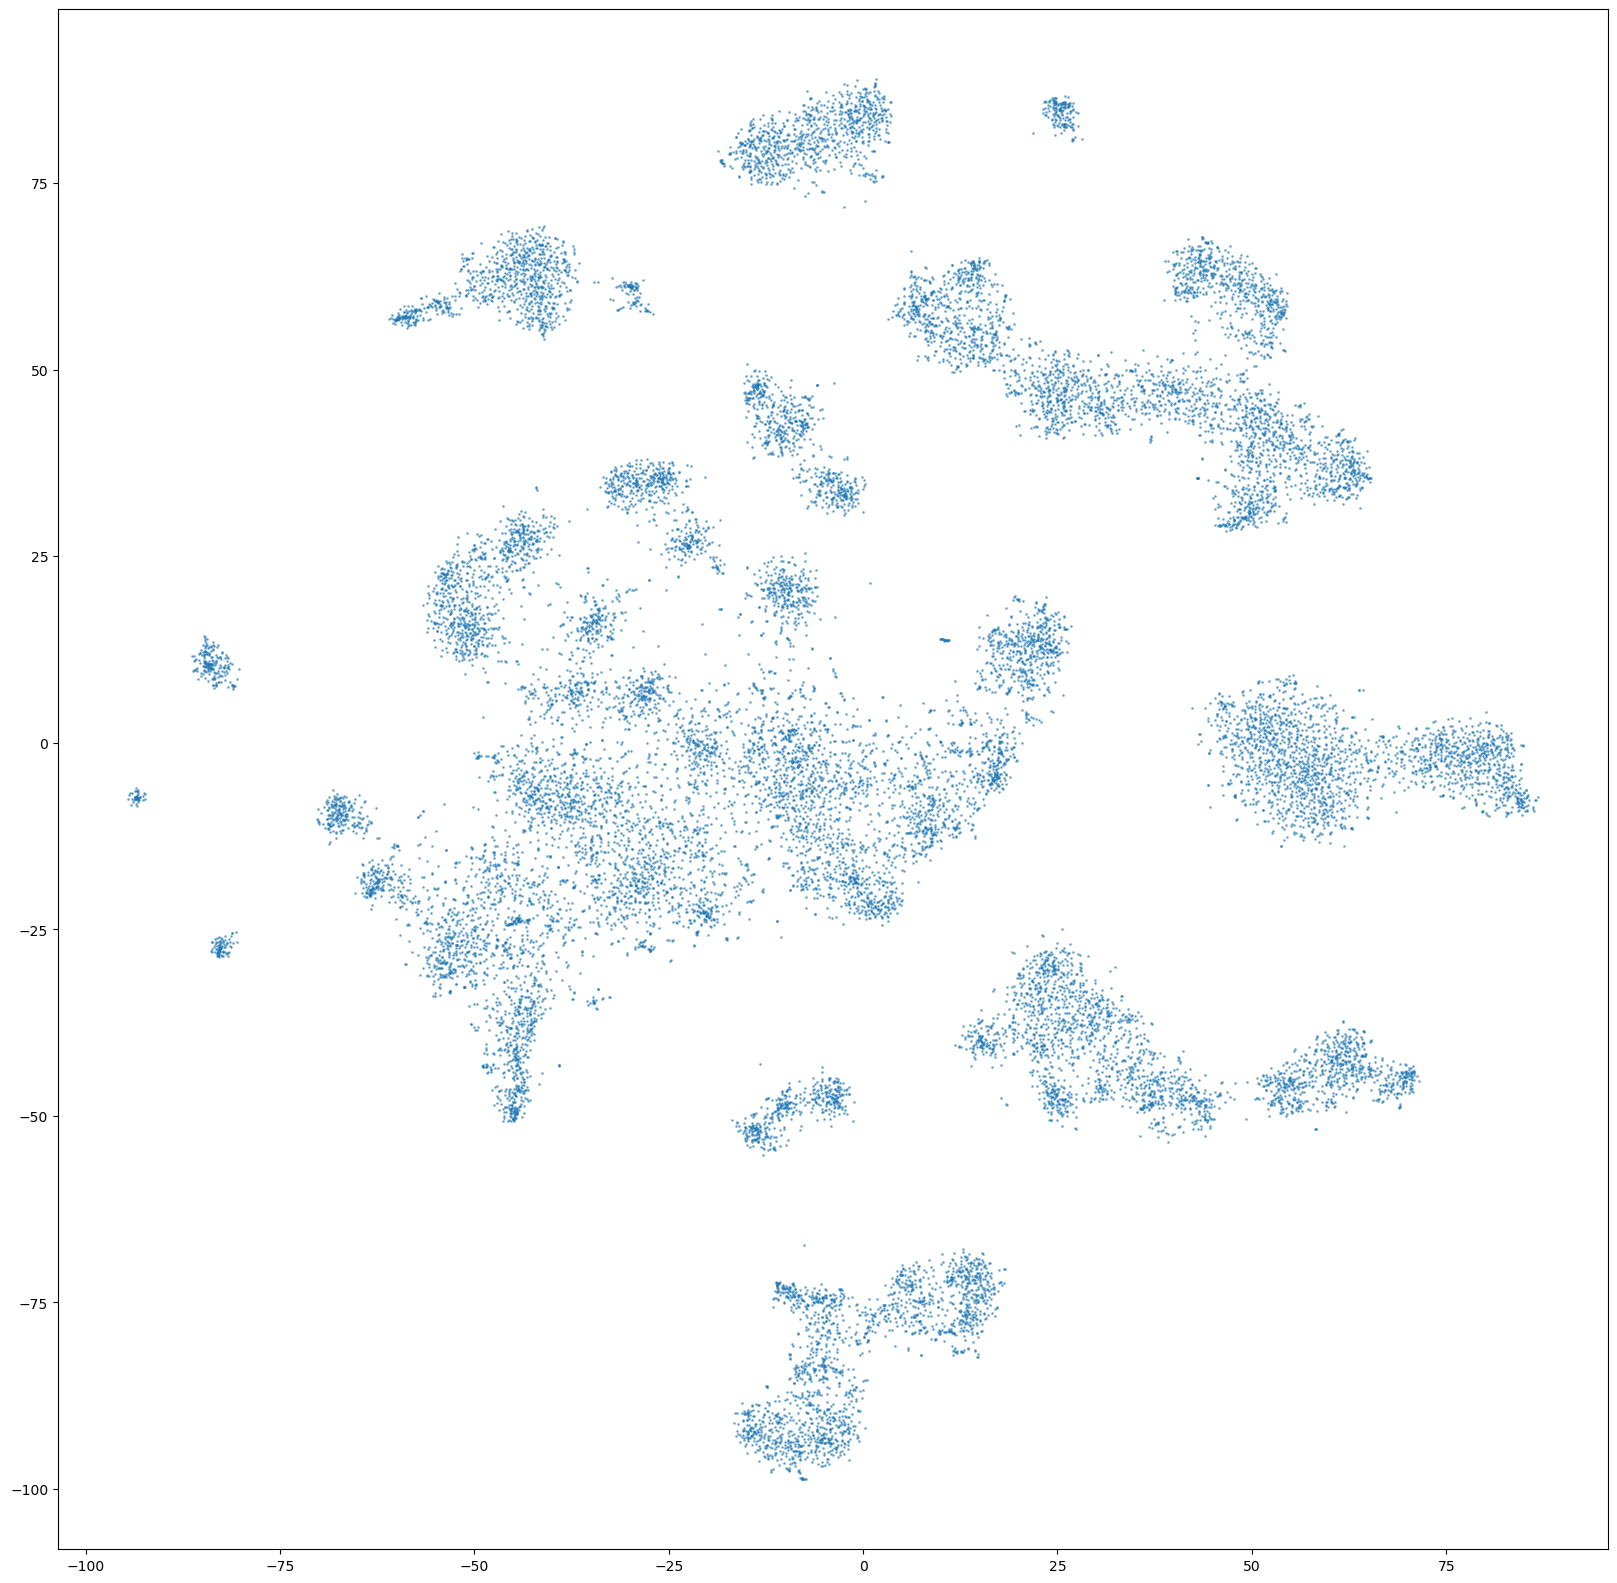

In [34]:
%matplotlib inline
fig,ax = plt.subplots(figsize = (20,20))
ax.plot(gaba_arr[:,0], gaba_arr[:,1], 'o', markersize=1, alpha=0.5)
plt.show()

Try K-means clustering

In [242]:
dir = gaba_iso_dir + 'integrated_cell_types/'
os.makedirs(dir + 'kmeans_plots/', exist_ok=True) 

In [250]:
for k in range(30,85,5):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(gaba_arr)
    labels = kmeans.labels_

    cmap = dict(zip(np.unique(labels), sns.color_palette("hsv", len(np.unique(labels)))))
    fig,ax = plt.subplots(figsize = (20,20))
    ax.set_box_aspect(1)
    ax.scatter(gaba_arr[:,0], gaba_arr[:,1], s=1, c=[cmap[x] for x in labels], alpha=0.5)
    arr_df = pd.DataFrame(gaba_arr, columns=['tsne-1','tsne-2'])
    for label in set(labels):
        if label != -1:
            cluster_median = arr_df[labels == label].median()
            ax.annotate(label, cluster_median, fontsize=8, color='black',
                        ha='center', va='center', bbox=dict(boxstyle='round', alpha=0.2))
    plt.xticks([])
    plt.yticks([])
    plt.title('K-Means Clustering of GABA Cells, k = ' + str(k))
    plt.savefig(dir + 'kmeans_plots/kmeans_gaba_k_' + str(k) + '.png', bbox_inches='tight')
    plt.close(fig)
    print(f'K-Means clustering plot saved for k = {k}')
    plt.show()

K-Means clustering plot saved for k = 30
K-Means clustering plot saved for k = 35
K-Means clustering plot saved for k = 40
K-Means clustering plot saved for k = 45
K-Means clustering plot saved for k = 50
K-Means clustering plot saved for k = 55
K-Means clustering plot saved for k = 60
K-Means clustering plot saved for k = 65
K-Means clustering plot saved for k = 70
K-Means clustering plot saved for k = 75
K-Means clustering plot saved for k = 80


K-Means clustering plot saved for k = 70


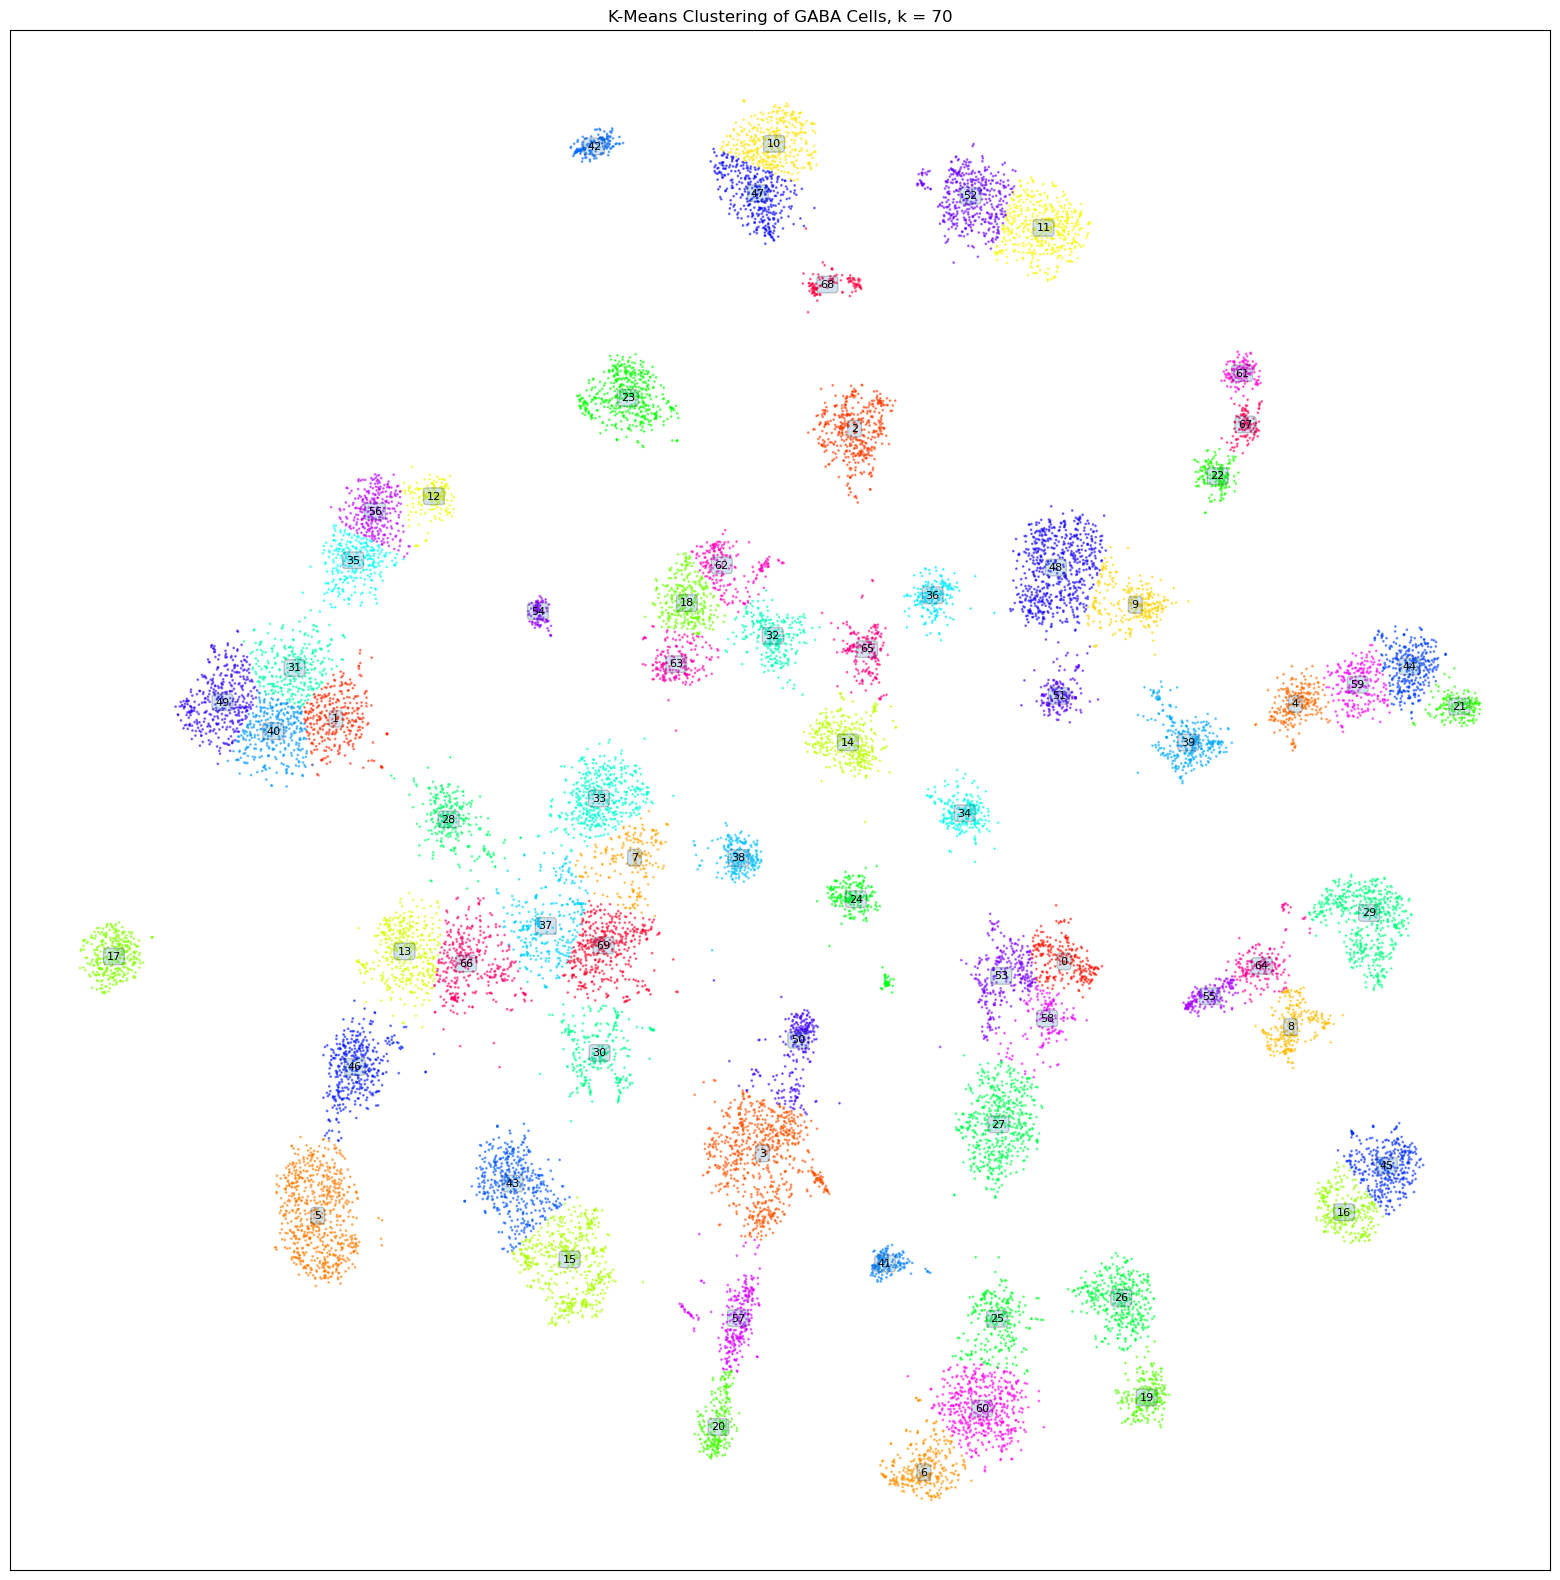

In [251]:
%matplotlib inline
k = 70
kmeans = KMeans(n_clusters=k, random_state=42).fit(gaba_arr)
labels = kmeans.labels_

cmap = dict(zip(np.unique(labels), sns.color_palette("hsv", len(np.unique(labels)))))
fig,ax = plt.subplots(figsize = (20,20))
ax.set_box_aspect(1)
ax.scatter(gaba_arr[:,0], gaba_arr[:,1], s=1, c=[cmap[x] for x in labels], alpha=0.5)
arr_df = pd.DataFrame(gaba_arr, columns=['tsne-1','tsne-2'])
for label in set(labels):
    if label != -1:
        cluster_median = arr_df[labels == label].median()
        ax.annotate(label, cluster_median, fontsize=8, color='black',
                    ha='center', va='center', bbox=dict(boxstyle='round', alpha=0.2))
plt.xticks([])
plt.yticks([])
plt.title('K-Means Clustering of GABA Cells, k = ' + str(k))
#plt.savefig(dir + 'kmeans_plots/kmeans_gaba_k_' + str(k) + '.png', bbox_inches='tight')
#plt.close(fig)
print(f'K-Means clustering plot saved for k = {k}')
plt.show()

In [274]:
df_marker, arr_tsne, meta_data_df_plis, linkage_cluster_order, df_marker_log_and_std_col, df_plis, cluster_indices, df_marker_log_and_std, pos, tg, tgfs, change_indices, linkage_alg, dist_metric = dp_int.process(df,gaba_meta_data_df,gaba_arr,'GABA',dir)

column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00


<IPython.core.display.Javascript object>

K-Means clustering plot saved for k = 70
verify raw prelinkage df and raw metadata df have same columns:
True


<IPython.core.display.Javascript object>

[36 66 69 37 33 13 18 11 52 47 10 42 61 67 34 14 22 48 23 63 32 38  7  2
 62 54 29 16 45 17 19  6 25 26 60 58 27 53  0 41 68  3 50 46 30 28 12 24
  9 51 65 39  4 59 44 21  8 64 55 56 35 31 40 49  1 15 43 57 20  5]


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{36: 1, 66: 2, 69: 3, 37: 4, 33: 5, 13: 6, 18: 7, 11: 8, 52: 9, 47: 10, 10: 11, 42: 12, 61: 13, 67: 14, 34: 15, 14: 16, 22: 17, 48: 18, 23: 19, 63: 20, 32: 21, 38: 22, 7: 23, 2: 24, 62: 25, 54: 26, 29: 27, 16: 28, 45: 29, 17: 30, 19: 31, 6: 32, 25: 33, 26: 34, 60: 35, 58: 36, 27: 37, 53: 38, 0: 39, 41: 40, 68: 41, 3: 42, 50: 43, 46: 44, 30: 45, 28: 46, 12: 47, 24: 48, 9: 49, 51: 50, 65: 51, 39: 52, 4: 53, 59: 54, 44: 55, 21: 56, 8: 57, 64: 58, 55: 59, 56: 60, 35: 61, 31: 62, 40: 63, 49: 64, 1: 65, 15: 66, 43: 67, 57: 68, 20: 69, 5: 70}
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69]
check if df plis columns equal metadata df plis columns:
[ True  True  True ...  True  True  True]
len marker_Genes_sorted 344
len marker_genes_sorted_final 344
column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.

<IPython.core.display.Javascript object>

saving heatmap..
True


In [275]:
dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/'

saving heatmap..


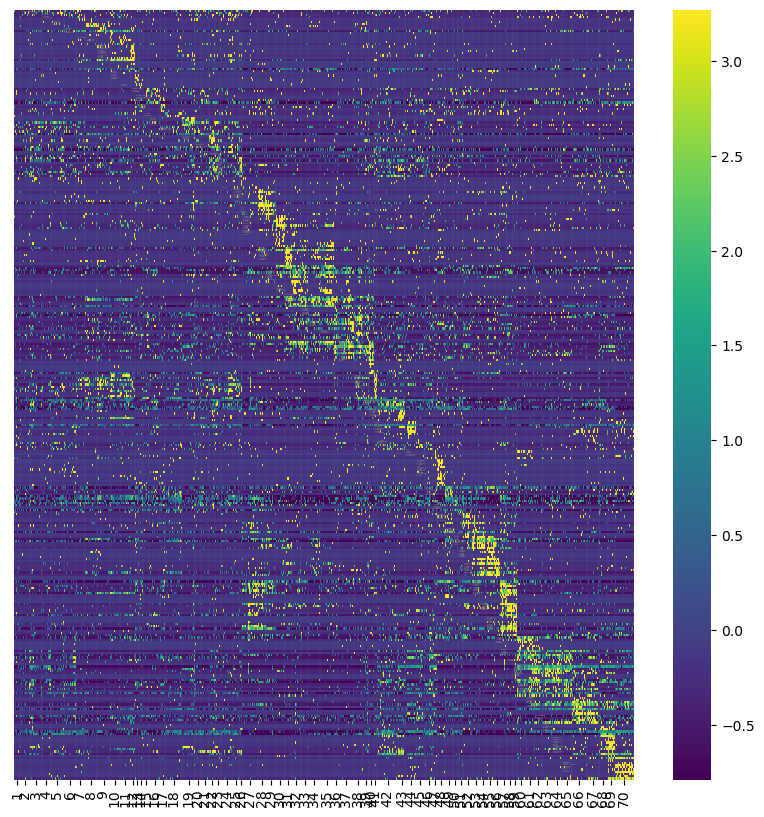

In [278]:
%matplotlib inline
cell_class = 'GABA'
fsw = 1.5
dp.plot_marker_heatmap(df_marker_log_and_std_col, 
                    pos, 
                    linkage_cluster_order, 
                    change_indices, 
                    tg, 
                    tgfs, 
                    linkage_alg,
                    dist_metric,
                    dir,
                    fs_waterfall = fsw,
                    savefig = True,
                    cell_class = str(cell_class) + '_heatmap',)
    

Try Louvain

In [35]:
dir = gaba_iso_dir + 'integrated_cell_types/'
os.makedirs(dir + 'louvain_plots/', exist_ok=True) 

In [284]:
gaba_hm_arr.shape

(21498, 36)

In [27]:
n_cells, n_pcs = gaba_hm_arr.shape
adata = anndata.AnnData(X = gaba_hm_arr)
adata.obsm['X_pca'] = gaba_hm_arr
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs, use_rep='X_pca')
sc.tl.louvain(adata, resolution=0.5, random_state=42)
labels = adata.obs['louvain'].astype(int).values


In [28]:
labels.shape

(21498,)

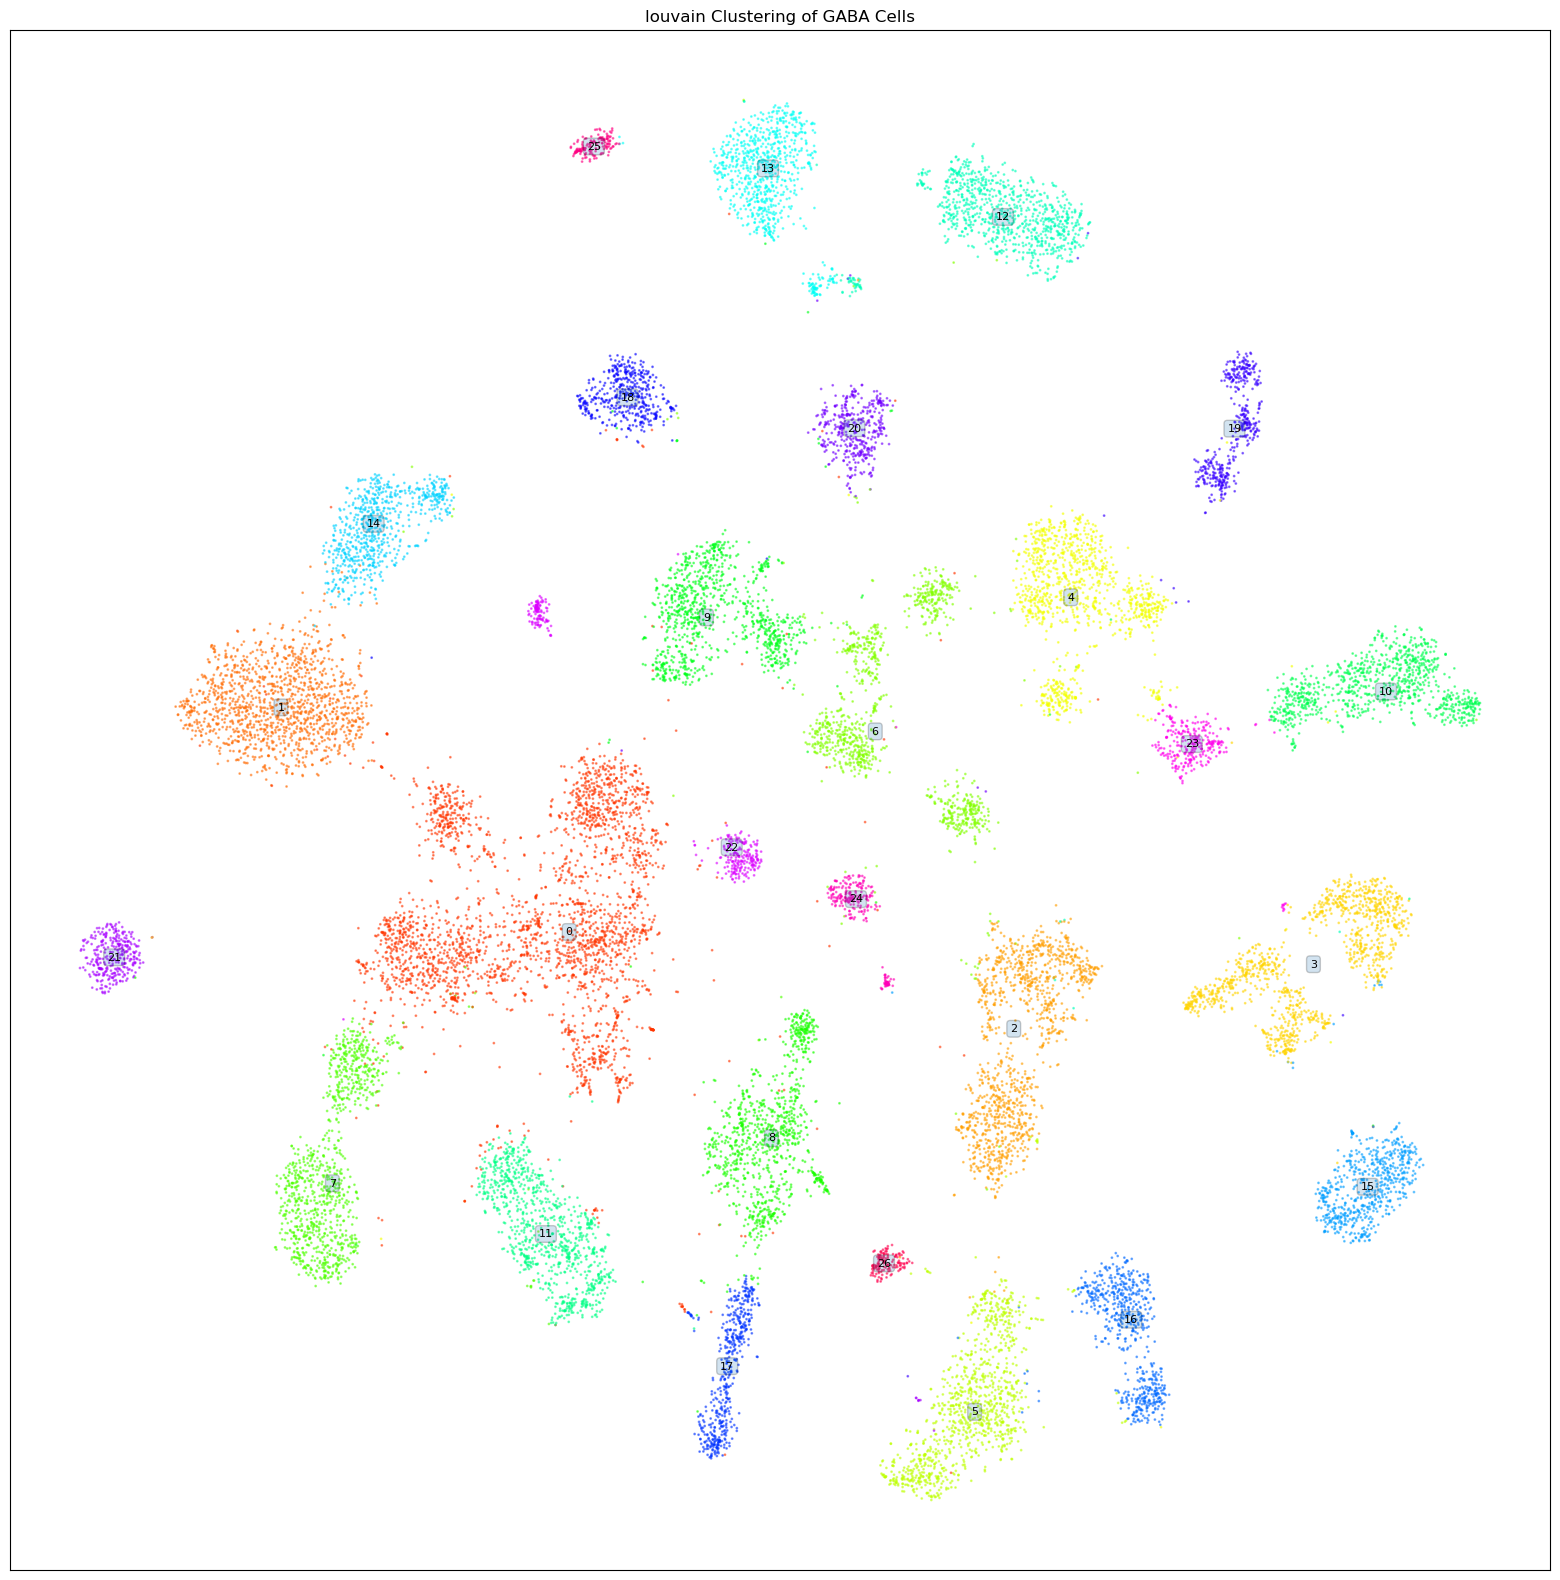

In [30]:
%matplotlib inline
cmap = dict(zip(np.unique(labels), sns.color_palette("hsv", len(np.unique(labels)))))
fig,ax = plt.subplots(figsize = (20,20))
ax.set_box_aspect(1)
ax.scatter(gaba_arr[:,0], gaba_arr[:,1], s=1, c=[cmap[x] for x in labels], alpha=0.5)
arr_df = pd.DataFrame(gaba_arr, columns=['tsne-1','tsne-2'])
for label in set(labels):
    if label != -1:
        cluster_median = arr_df[labels == label].median()
        ax.annotate(label, cluster_median, fontsize=8, color='black',
                    ha='center', va='center', bbox=dict(boxstyle='round', alpha=0.2))
plt.xticks([])
plt.yticks([])
plt.title('louvain Clustering of GABA Cells')
#plt.savefig(dir + 'louvain.png', bbox_inches='tight')
#plt.close(fig)
plt.show()

In [45]:
use_gauss = False
metric = 'correlation'
for n_neighbors in [3,4,5]:
    n_cells, n_pcs = gaba_hm_arr.shape
    adata = anndata.AnnData(X = gaba_hm_arr)
    adata.obsm['X_pca'] = gaba_hm_arr
    if use_gauss:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, knn=False, method='gauss', use_rep='X_pca')
    else:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, metric=metric,use_rep='X_pca')
    sc.tl.louvain(adata, resolution=0.5, random_state=42)
    labels = adata.obs['louvain'].astype(int).values

    cmap = dict(zip(np.unique(labels), sns.color_palette("hsv", len(np.unique(labels)))))
    fig,ax = plt.subplots(figsize = (20,20))
    ax.set_box_aspect(1)
    ax.scatter(gaba_arr[:,0], gaba_arr[:,1], s=1, c=[cmap[x] for x in labels], alpha=0.5)
    arr_df = pd.DataFrame(gaba_arr, columns=['tsne-1','tsne-2'])
    for label in set(labels):
        if label != -1:
            cluster_median = arr_df[labels == label].median()
            ax.annotate(label, cluster_median, fontsize=8, color='black',
                        ha='center', va='center', bbox=dict(boxstyle='round', alpha=0.2))
    plt.xticks([])
    plt.yticks([])
    if use_gauss:
        plt.title('louvain gauss Clustering of GABA Cells with n_neighbors = ' + str(n_neighbors) + ' metric = ' + str(metric))
    else:
        plt.title('louvain Clustering of GABA Cells with n_neighbors = ' + str(n_neighbors) + ' metric = ' + str(metric))
    if use_gauss:
        plt.savefig(dir + 'louvain_plots/louvain_gauss_gaba_' + str(n_neighbors) + ' metric = ' + str(metric) + '.png', bbox_inches='tight')
    else:
        plt.savefig(dir + 'louvain_plots/louvain_gaba_' + str(n_neighbors) + ' metric = ' + str(metric) + '.png', bbox_inches='tight')
    plt.close(fig)
    #plt.show()



/home/isaac/anaconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/isaac/anaconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/isaac/anaconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


params for dbscan
minpts:  20
epsilon percentile 65
epsilon:  1.4208255929870197

running dbscan with epsilon: 1.4208255929870197  and minpts: 20
Estimated number of clusters: 65
Estimated number of noise points: 2637


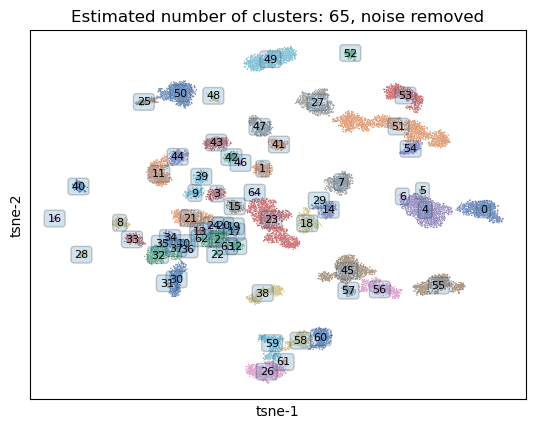

In [35]:
%matplotlib inline
epsilon, minpts = dp.compute_eps(minpts = 20, eps_prc=65, arr= gaba_arr)
labels,n_clusters, arr = dp.do_dbscan(epsilon = epsilon, minpts = 20, arr = gaba_arr)

In [37]:
gaba_arr.shape

(21498, 2)

In [36]:
labels.shape

(18861,)

In [38]:
noise_idx = np.where(labels == -1)[0]
noise_idx

array([], dtype=int64)

running dbscan with epsilon: 1.4208255929870197  and minpts: 20
Estimated number of clusters: 65
Estimated number of noise points: 2637


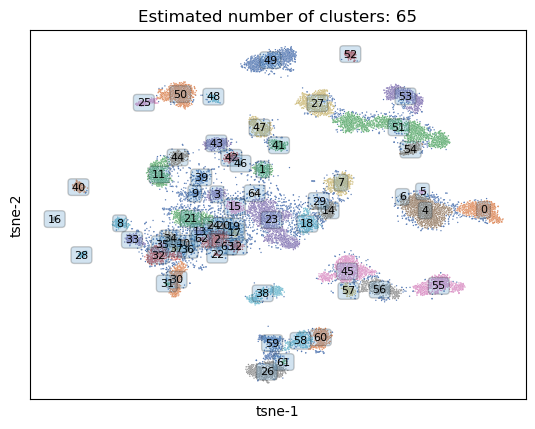

In [39]:
labels_wn,n_clusters_wn, arr_wn = dp.do_dbscan_keep_noise(epsilon = epsilon, minpts = 20, arr = gaba_arr)

running dbscan with epsilon: 1.5748041796947179  and minpts: 20
Estimated number of clusters: 46
Estimated number of noise points: 1554
[    5    10    14 ... 20530 21421 21485]


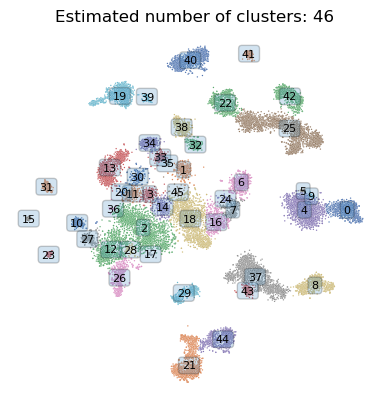

In [83]:
#epsilon, minpts = dp.compute_eps(minpts = 20, eps_prc=75, arr= gaba_arr)
labels_wn,n_clusters_wn, arr_wn = dp.do_dbscan_keep_noise(epsilon = epsilon, minpts = 20, arr = gaba_arr)

In [84]:
np.where(labels_wn == -1)[0]

array([], dtype=int64)

In [75]:
labels_wn[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [68]:
Counter(labels_wn)

Counter({25: 1882,
         2: 1562,
         37: 1497,
         18: 1384,
         4: 1308,
         21: 1084,
         19: 891,
         40: 880,
         13: 791,
         12: 789,
         8: 736,
         0: 735,
         22: 719,
         44: 684,
         42: 632,
         26: 558,
         6: 524,
         16: 473,
         29: 433,
         38: 392,
         34: 336,
         7: 290,
         1: 268,
         14: 231,
         27: 231,
         3: 229,
         10: 224,
         32: 213,
         31: 207,
         41: 171,
         11: 164,
         30: 162,
         43: 155,
         33: 141,
         23: 114,
         39: 83,
         15: 65,
         -1: 40,
         28: 40,
         17: 31,
         24: 25,
         5: 24,
         45: 24,
         36: 23,
         20: 20,
         35: 18,
         9: 15})

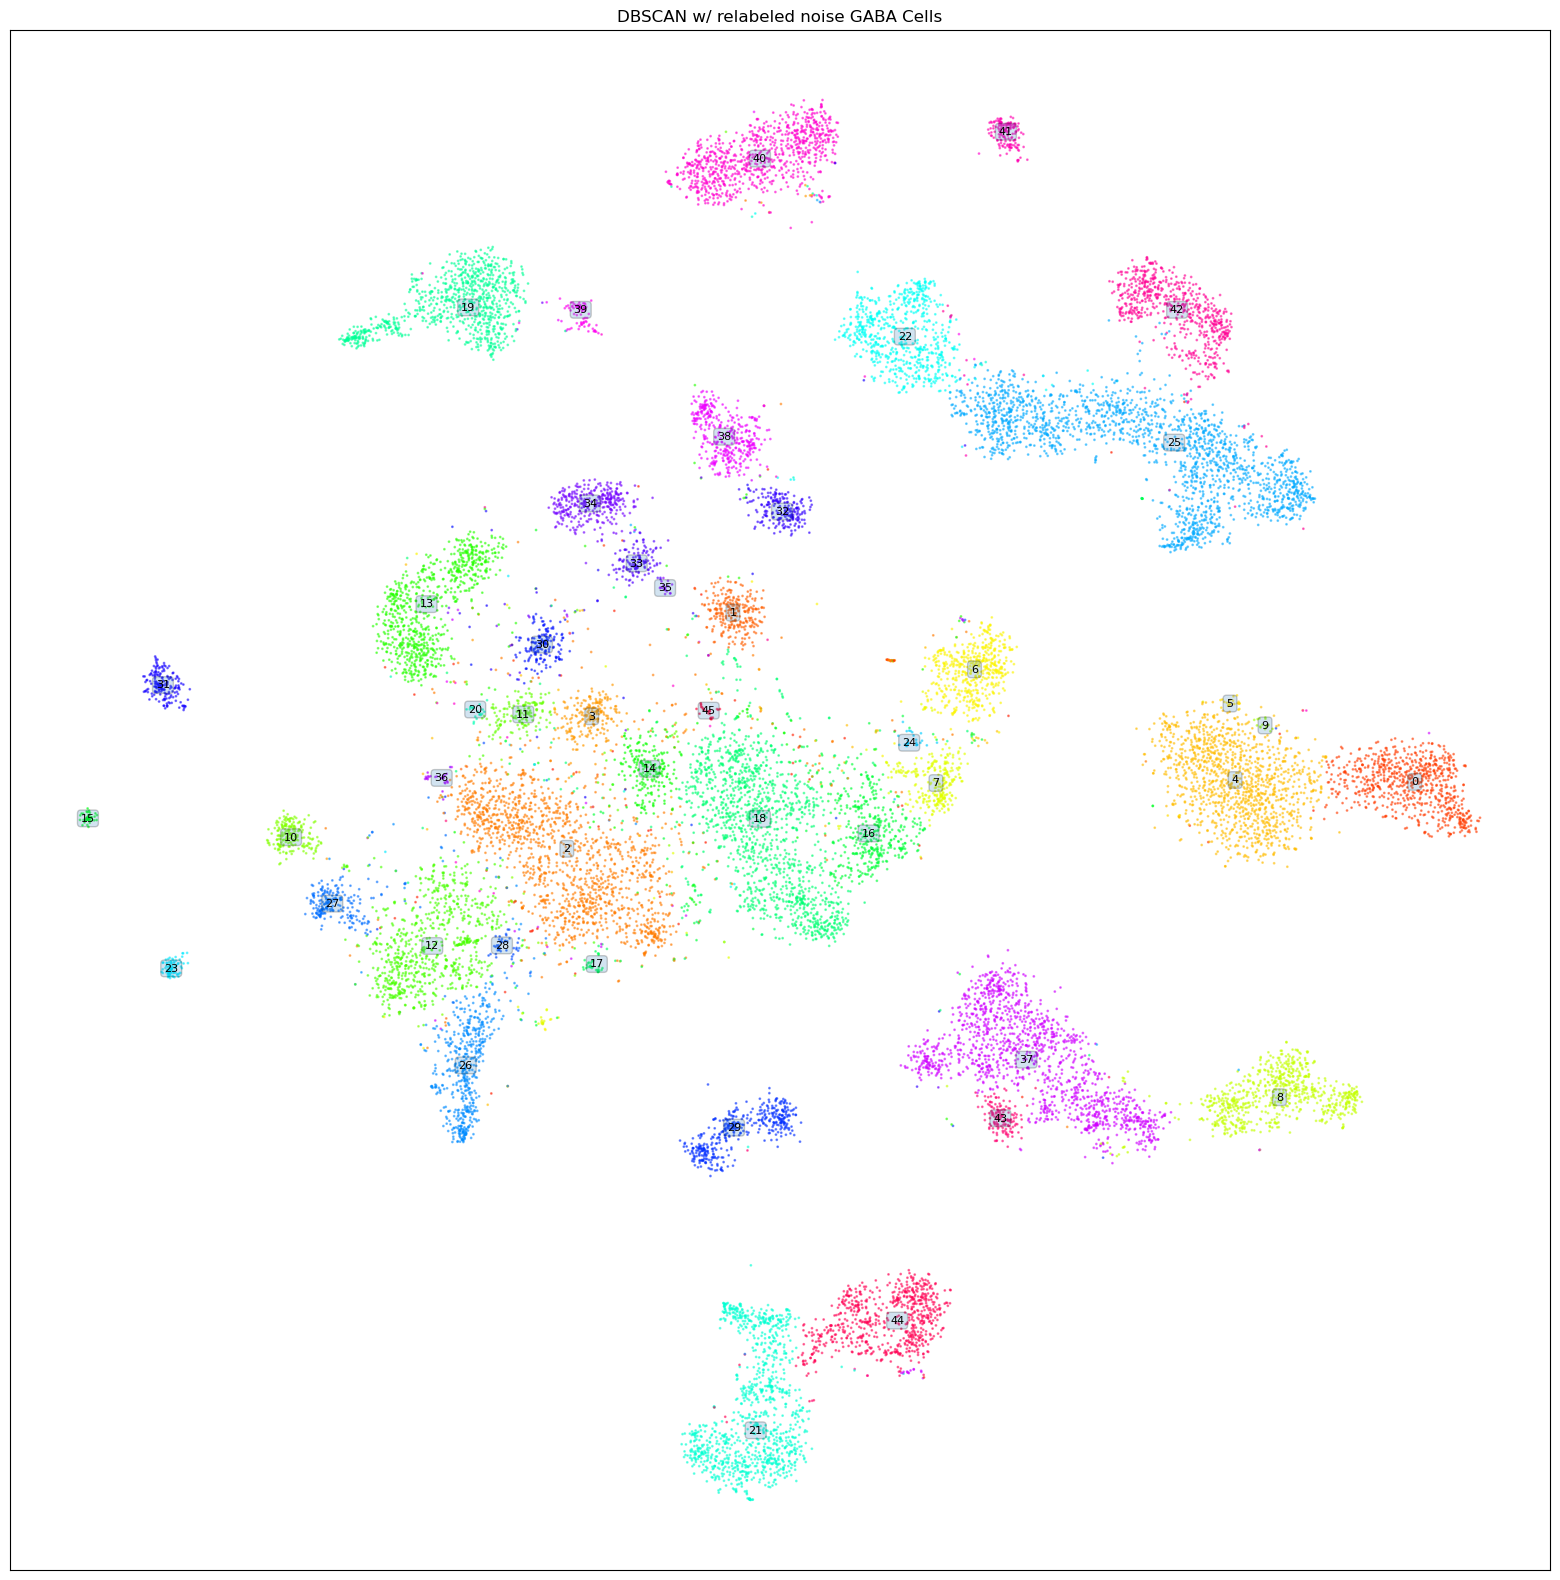

In [45]:
%matplotlib inline
cmap = dict(zip(np.unique(labels_wn), sns.color_palette("hsv", len(np.unique(labels_wn)))))
fig,ax = plt.subplots(figsize = (20,20))
ax.set_box_aspect(1)
ax.scatter(gaba_arr[:,0], gaba_arr[:,1], s=1, c=[cmap[x] for x in labels_wn], alpha=0.5)
arr_df = pd.DataFrame(gaba_arr, columns=['tsne-1','tsne-2'])
for label in set(labels_wn):
    if label != -1:
        cluster_median = arr_df[labels_wn == label].median()
        ax.annotate(label, cluster_median, fontsize=8, color='black',
                    ha='center', va='center', bbox=dict(boxstyle='round', alpha=0.2))
plt.xticks([])
plt.yticks([])
plt.title('DBSCAN w/ relabeled noise GABA Cells')
#plt.savefig(dir + 'louvain.png', bbox_inches='tight')
#plt.close(fig)
plt.show()

In [46]:
dir

<function dir>

column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00
params for dbscan
minpts:  30
epsilon percentile 80
epsilon:  2.0532516082265797



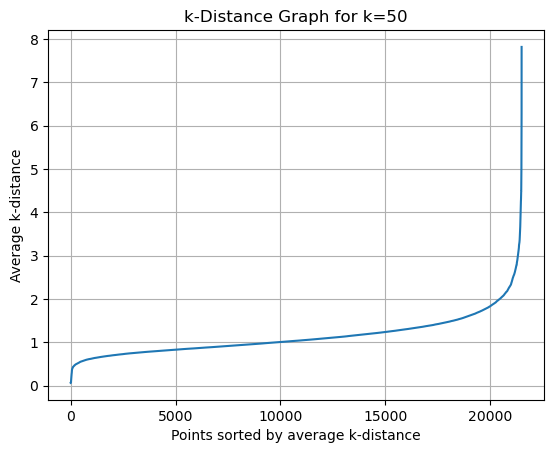

The knee is at x = 20813, y = 2.184147069430655


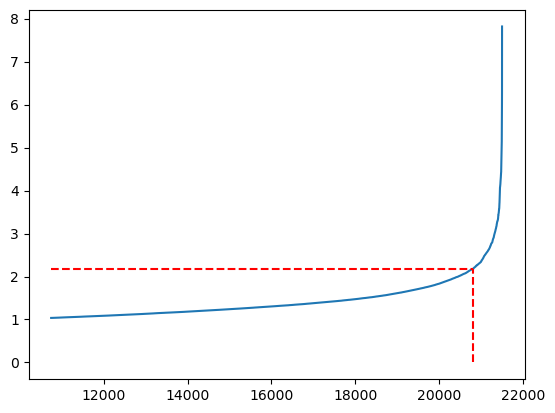

Optimal epsilon: 2.184147069430655
running dbscan with epsilon: 2.0532516082265797  and minpts: 30
Estimated number of clusters: 33
Estimated number of noise points: 1005


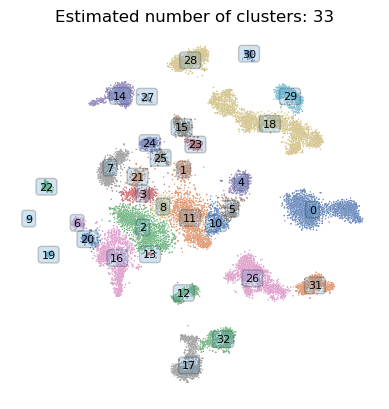

verify raw prelinkage df and raw metadata df have same columns:
True


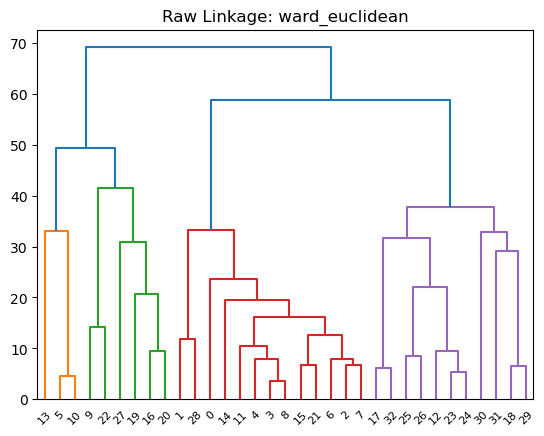

[22  9 19 20 16 27  5 10 13  0 11  3  8  4 15 21  2  7  6 14 28  1 17 32
 12 24 23 25 26 31 29 18 30]


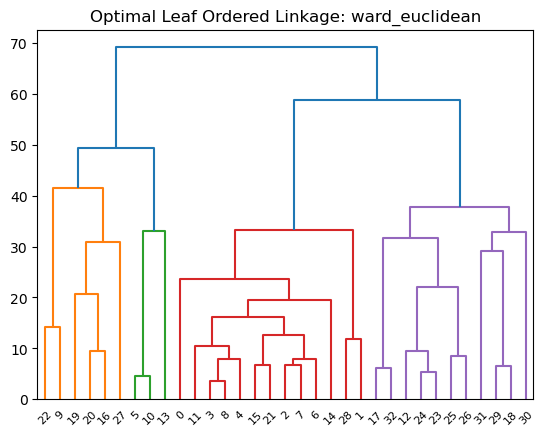

metadata df shape post inter cluster sort
(9, 21498)


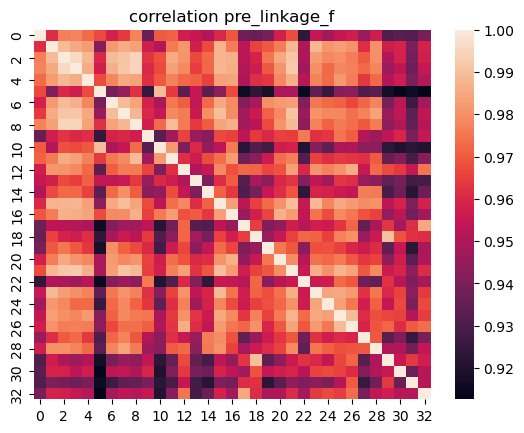

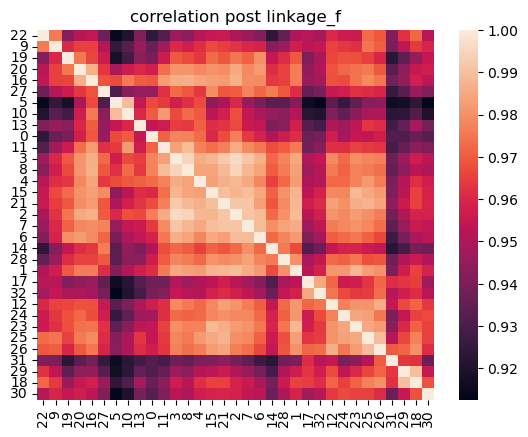

{22: 1, 9: 2, 19: 3, 20: 4, 16: 5, 27: 6, 5: 7, 10: 8, 13: 9, 0: 10, 11: 11, 3: 12, 8: 13, 4: 14, 15: 15, 21: 16, 2: 17, 7: 18, 6: 19, 14: 20, 28: 21, 1: 22, 17: 23, 32: 24, 12: 25, 24: 26, 23: 27, 25: 28, 26: 29, 31: 30, 29: 31, 18: 32, 30: 33}
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32]
check if df plis columns equal metadata df plis columns:
[ True  True  True ...  True  True  True]
len marker_Genes_sorted 206
len marker_genes_sorted_final 206
column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 187, 252, 346, 581, 1968, 2055, 2397, 2816, 2853, 4859, 6317, 6752, 7034, 7593, 7982, 8192, 9764, 10575, 10785, 11661, 12545, 12856, 13925, 14629, 15055, 15402, 15629, 15800, 17363, 18091, 18724, 21339, 21497]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
31
[array([  0,   1,   2,   4, 171,  88,  8

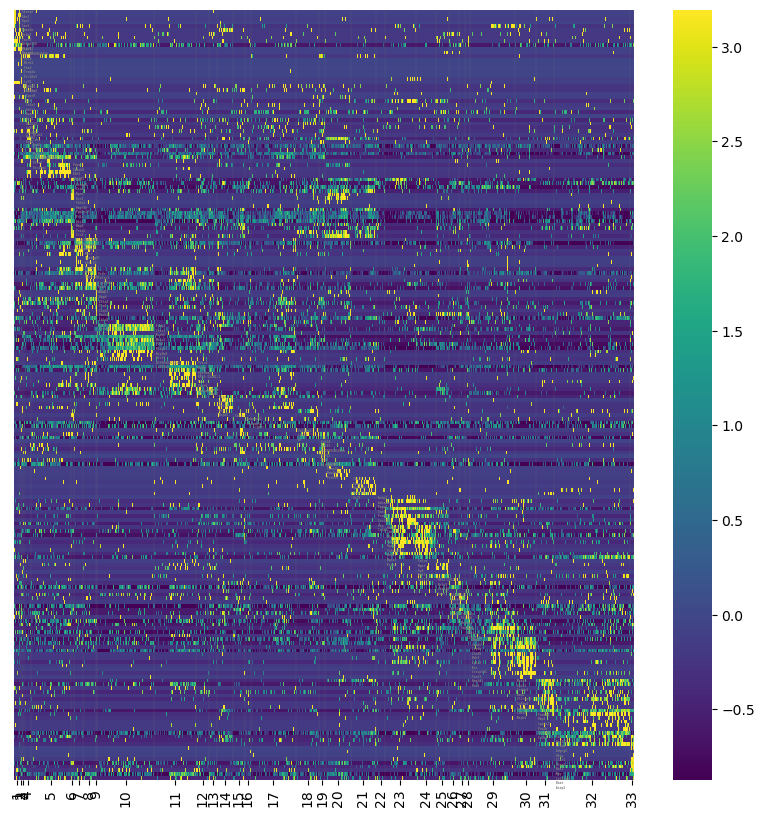

True


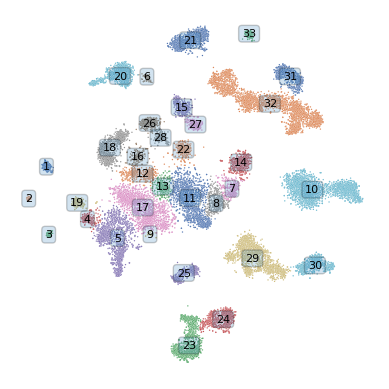

writing to file...


In [462]:
integrated_cell_types_dir = gaba_iso_dir + 'integrated_cell_types/'
df_marker, arr_tsne, meta_data_df_plis, linkage_cluster_order, df_marker_log_and_std_col, df_plis, cluster_indices, df_marker_log_and_std, pos, tg, tgfs, change_indices, linkage_alg, dist_metric = dp_int.process(df,gaba_meta_data_df,gaba_arr,'GABA',integrated_cell_types_dir,write_to_file=True)

/tmp/ipykernel_3900525/1385371061.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(linkage_cluster_order, rotation = 90)


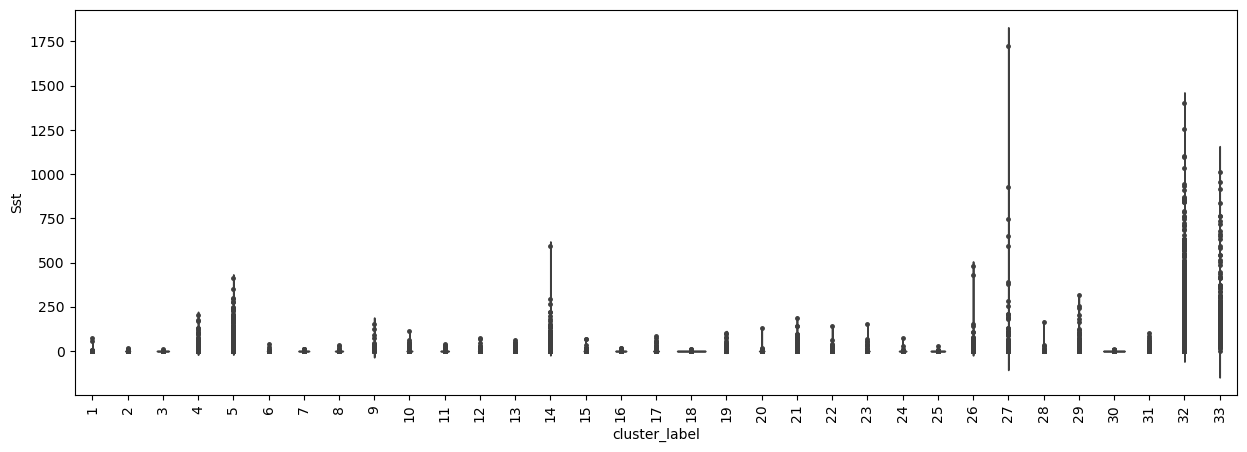

In [463]:
#check some specific expression of genes
gene = 'Sst'
%matplotlib inline
fig,ax = plt.subplots(figsize = (15,5))
sns.violinplot(x=meta_data_df_plis.T['cluster_label'], y=df_plis.T[gene], inner = 'point')
#sns.stripplot(x=amy_vglut2_md.T['full_name'], y=amy_vglut2_ce_ge_cv_ls.T[gene], color="k", size=3)
ax.set_xticklabels(linkage_cluster_order, rotation = 90)
plt.show()

In [464]:
out_dir = integrated_cell_types_dir + str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'

saving heatmap..


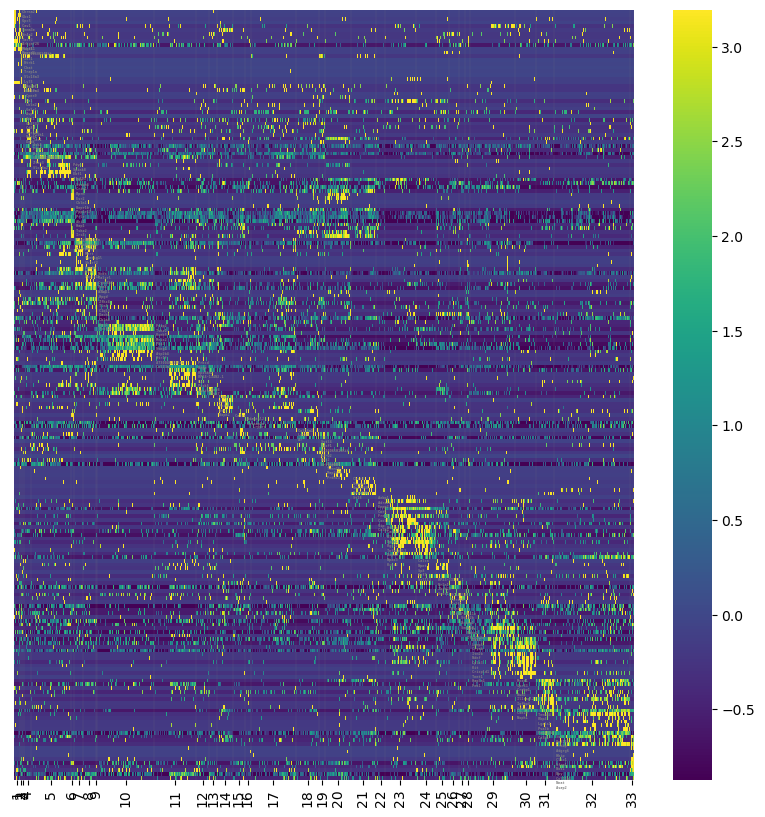

In [465]:
%matplotlib inline
cell_class = 'GABA'
fsw = 2.5
dp.plot_marker_heatmap(df_marker_log_and_std_col, 
                    pos, 
                    linkage_cluster_order, 
                    change_indices, 
                    tg, 
                    tgfs, 
                    linkage_alg,
                    dist_metric,
                    out_dir,
                    fs_waterfall = fsw,
                    savefig = True,
                    cell_class = str(cell_class))

Updated tsne with cluster labels matching heatmap

In [151]:
cell_class

'GABA'

In [466]:
out_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/GABA_l2_processed_eps_prc_80_minpts_30/'

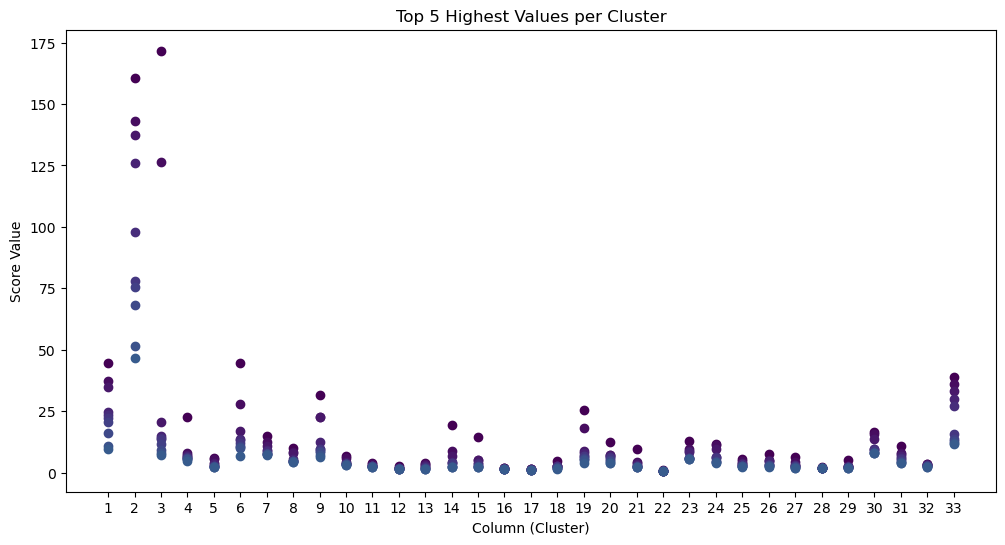

In [90]:
%matplotlib inline
top_genes, top_values = dp.get_top_scores(out_dir, cell_class, top_n=10)

In [92]:
top_genes[27]

['Pcdh11x',
 'Scg2',
 'Stxbp6',
 'Megf11',
 'Sema6d',
 'Vgf',
 'Brinp1',
 'Btbd3',
 'Pvrl1',
 'Rnf152']

In [469]:
int_marker_labels_df, meta_data_df_int = dp.get_integrated_marker_names(meta_data_df_plis,top_genes,cell_class, out_dir,write_to_file=True)

In [421]:
meta_data_df_int

,AATTCCTCAGCTACAT-1_10X51_4,AGGCTGCCACAATGCT-1_10X52_4,TAACTTCCATCGTCCT-1_10X51_4,GTTAGTGGTACTCCGG-1_10X51_4,TTCCGTGCAGACTCTA-1_10X52_2,ATTCAGGGTGCATCTA-1_10X52_4,TCGACCTGTGAGTAAT-1_10X51_3,GAAGGACTCAGACCCG-1_10X52_2,GGTTGTAAGTCACTGT-1_10X52_1,CCGATCTGTCCTTGTC-1_10X52_1,...,AGCTTCCTCAAGGCTT-1_10X35_2,ACCACAAGTATAGGGC-1_10X35_2,GTGGTTATCCGATCGG-1_19-1,CAATACGGTATTCCTT-1_42-1,ACAGCCGTCAACACGT-1_46-1,CGAAGGACACACAGCC-1_75-1,TGAGGTTCACTTGTCC-1_76-2,TACAGGTGTTTACACG-1_74-2,GGGTGTCAGCACACAG-1_41-1,TTTCACATCTCGGGAC-1_46-2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
SampleID,10X51_4,10X52_4,10X51_4,10X51_4,10X52_2,10X52_4,10X51_3,10X52_2,10X52_1,10X52_1,...,10X35_2,10X35_2,10X19_1,10X42_1,10X46_1,10X75_1,10X76_2,10X74_2,10X41_1,10X46_2
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,sd,sd,amy,amy,amy,amy,amy,amy,amy,amy
Age,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,...,8w,8w,~7w,11.5w,10w,8w,8w,8w,9.5w,10w
Group,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-F,Breeder-M,Breeder-M,Breeder-F,Breeder-F,Breeder-F,...,Naïve-F,Naïve-F,2h,8h,8h,recall,2h,naïve,24h,8h
Sex,M,M,M,M,F,M,M,F,F,F,...,F,F,M,M,M,M,M,M,M,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,32,32,32,32,32,32,32,32,32,32


In [470]:
arr_df_sorted = pd.read_feather(out_dir + 'arr_df_sorted.feather')
arr_df_sorted

,tsne-1,tsne-2,labels
6244,-83.598793,7.732166,22
6223,-83.640167,12.626617,22
6207,-81.109932,7.699427,22
6206,-84.337906,10.238721,22
6205,-81.935234,9.602677,22
...,...,...,...
8413,25.588627,82.942360,30
8407,24.262167,83.486130,30
8408,25.979322,85.814034,30
8415,27.016693,84.993347,30


In [686]:
labels = np.array(arr_df_sorted.loc[:,'labels'])
labels

array([22, 22, 22, ..., 30, 30, 30], dtype=int32)

In [472]:
df_tmp  = df.reindex(columns = meta_data_df_plis.columns)

In [473]:
column_sums = df_tmp.loc[:,df_tmp.columns].sum(axis=0)
df_n = df_tmp.div(column_sums)
#scale by norm_scale_factor
df_n = df_n.multiply(20000)

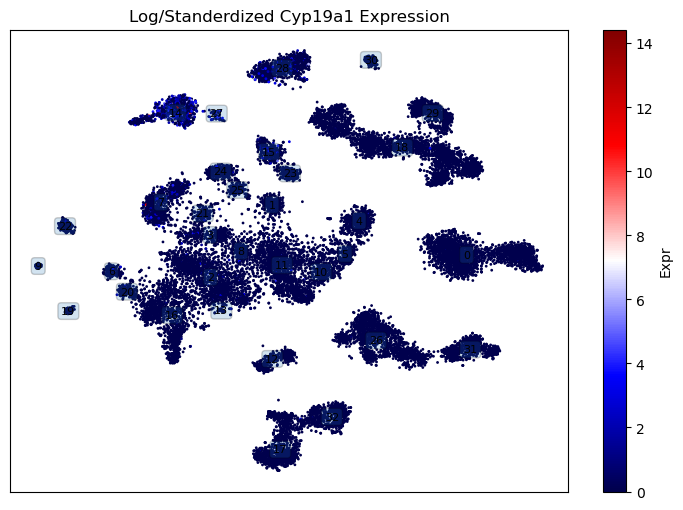

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1970: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(linkage_cluster_order, rotation = 90)


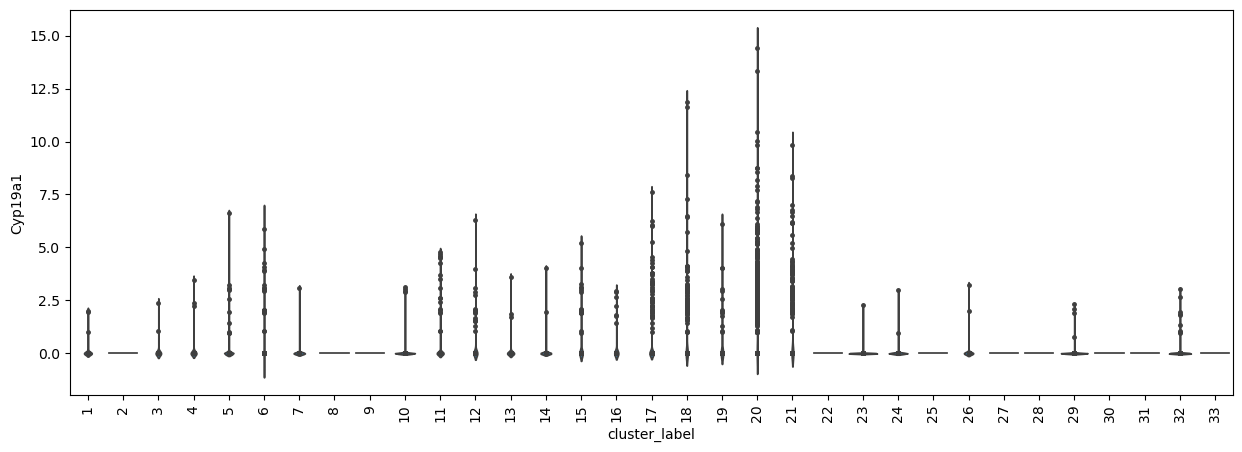

In [690]:
%matplotlib inline
gene = 'Cyp19a1'
dp.plot_marker_on_tsne(arr_df_sorted, df_n, gene, labels)
dp.check_gene_cluster_expression(df_n, meta_data_df_plis, gene, linkage_cluster_order)

In [510]:
out_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/GABA_l2_processed_eps_prc_80_minpts_30/'

Load finalized marker names

In [ ]:
cell_class = 'GABA'
out_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
labels

['Lhx8-Th',
 'Chat-Vip',
 'Gal-Avp',
 'Isl1-Tac1',
 'Pdyn-Ebf1',
 'Prlr-Cbln1',
 'Adora2a-Scn4b',
 'Adora2a-Penk',
 'C1ql1-Dach1',
 'Foxp2-Tshz1',
 'Prkcd-Ezr',
 'Fign-Tshz2',
 'Pax6-Cyp26a1',
 'Fign-Ucn3',
 'Prlr-Calcr',
 'Cntnap5a-Brinp3',
 'Fign-Lrpprc',
 'Greb1-Prlr',
 'Isl1-Sytl4',
 'Cartpt-Cbln1',
 'Prlr-St18',
 'Scg2-Ahi1',
 'Vip-Sncg',
 'Htr3a-Rgs12',
 'Npnt-Calca',
 'Lhx6-Cbln4',
 'Satb1-Sst',
 'Scg2-Pcdh11x',
 'Reln-Ndnf',
 'Lamp5-Kit',
 'Moxd1-Igfbp4',
 'Sst-Crhbp',
 'Sst-Npy']

In [513]:
meta_data_df_plis_f = meta_data_df_plis.copy()

In [515]:
meta_data_df_plis_f = meta_data_df_plis_f.drop('markers')
meta_data_df_plis_f = meta_data_df_plis_f.drop('full_name')

In [516]:
meta_data_df_plis_f

,AGCCAGCCAAATGCGG-1_19-1,TGTGGCGTCGGAATGG-1_19-1,CCTCAGTGTCGCGTTG-1_19-1,TGAATCGTCGCTATTT-1_19-1,GTTAGACAGAGAGTGA-1_19-1,TTGAGTGTCTGAGCAT-1_10X36_1,CATCCCATCGTGCGAC-1_19-1,GGGTGTCAGACAGTCG-1_10X38_1,AGACAGGGTGAGCAGT-1_19-1,CAGGTATCACTAGAGG-1_08-1,...,CCTCCAATCGCCTCTA-1_10X36_2,AATGGAATCTCGGGAC-1_10X51_2,TTGACCCAGCTCATAC-1_10X51_2,GCGGAAACAAAGTGTA-1_10X35_2,TGACGCGCAGTTGCGC-1_10X35_1,TGATTTCGTTTGCCGG-1_10X35_1,AGTAGTCGTTCTCTCG-1_10X36_1,CCGGGTAGTAGCTGAG-1_10X36_1,CTACCTGGTTCGGCGT-1_10X51_2,AGCGATTCACACGGTC-1_18-1
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
SampleID,10X19_1,10X19_1,10X19_1,10X19_1,10X19_1,10X36_1,10X19_1,10X38_1,10X19_1,10X08_1,...,10X36_2,10X51_2,10X51_2,10X35_2,10X35_1,10X35_1,10X36_1,10X36_1,10X51_2,10X18_1
dataset,amy,amy,amy,amy,amy,sd,amy,sd,amy,amy,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,amy
Age,~7w,~7w,~7w,~7w,~7w,8.5w,~7w,9w,~7w,8.5w,...,8.5w,11-12w,11-12w,8w,8w,8w,8.5w,8.5w,11-12w,~8w
Group,2h,2h,2h,2h,2h,Naïve-M,2h,Naïve-F,2h,naïve,...,Naïve-M,Breeder-F,Breeder-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,2h
Sex,M,M,M,M,M,M,M,F,M,M,...,M,F,F,F,F,F,M,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,33,33,33,33,33,33,33,33,33,33


In [517]:
linkage_cluster_order

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])

In [518]:
meta_data_df_plis_f = dp.update_metadata_w_markers(out_dir,meta_data_df_plis_f,linkage_cluster_order, labels, cell_class, write_to_file=True)

In [519]:
meta_data_df_plis_f

,AGCCAGCCAAATGCGG-1_19-1,TGTGGCGTCGGAATGG-1_19-1,CCTCAGTGTCGCGTTG-1_19-1,TGAATCGTCGCTATTT-1_19-1,GTTAGACAGAGAGTGA-1_19-1,TTGAGTGTCTGAGCAT-1_10X36_1,CATCCCATCGTGCGAC-1_19-1,GGGTGTCAGACAGTCG-1_10X38_1,AGACAGGGTGAGCAGT-1_19-1,CAGGTATCACTAGAGG-1_08-1,...,CCTCCAATCGCCTCTA-1_10X36_2,AATGGAATCTCGGGAC-1_10X51_2,TTGACCCAGCTCATAC-1_10X51_2,GCGGAAACAAAGTGTA-1_10X35_2,TGACGCGCAGTTGCGC-1_10X35_1,TGATTTCGTTTGCCGG-1_10X35_1,AGTAGTCGTTCTCTCG-1_10X36_1,CCGGGTAGTAGCTGAG-1_10X36_1,CTACCTGGTTCGGCGT-1_10X51_2,AGCGATTCACACGGTC-1_18-1
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
SampleID,10X19_1,10X19_1,10X19_1,10X19_1,10X19_1,10X36_1,10X19_1,10X38_1,10X19_1,10X08_1,...,10X36_2,10X51_2,10X51_2,10X35_2,10X35_1,10X35_1,10X36_1,10X36_1,10X51_2,10X18_1
dataset,amy,amy,amy,amy,amy,sd,amy,sd,amy,amy,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,amy
Age,~7w,~7w,~7w,~7w,~7w,8.5w,~7w,9w,~7w,8.5w,...,8.5w,11-12w,11-12w,8w,8w,8w,8.5w,8.5w,11-12w,~8w
Group,2h,2h,2h,2h,2h,Naïve-M,2h,Naïve-F,2h,naïve,...,Naïve-M,Breeder-F,Breeder-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,2h
Sex,M,M,M,M,M,M,M,F,M,M,...,M,F,F,F,F,F,M,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,33,33,33,33,33,33,33,33,33,33
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy


saving heatmap..


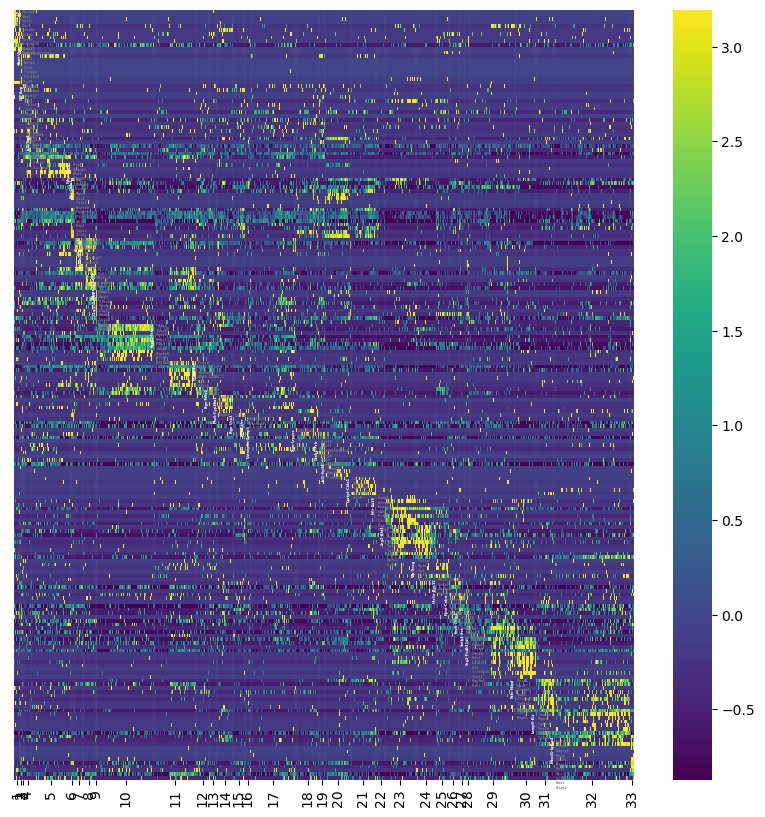

In [ ]:
linkage_alg = 'ward'
dist_metric = 'euclidean'
#GABA_tg_f, GABA_tgfs_f = dp.get_heatmap_labels(GABA_mgs_f, GABA_ind_f, GABA_ind_s_f)
#sanity check - plotting only filtered gaba_df (clusters removed)
dp.plot_marker_heatmap(df_marker_log_and_std_col, 
                       pos, 
                       linkage_cluster_order, 
                       change_indices, 
                       tg, 
                       tgfs, 
                       linkage_alg,
                       dist_metric,
                       out_dir,
                       fs_waterfall = 2.5,
                       cluster_labels = labels,
                       savefig = True,
                       cell_class = 'GABA_labeled')

In [523]:
labels

['Lhx8-Th',
 'Chat-Vip',
 'Gal-Avp',
 'Isl1-Tac1',
 'Pdyn-Ebf1',
 'Prlr-Cbln1',
 'Adora2a-Scn4b',
 'Adora2a-Penk',
 'C1ql1-Dach1',
 'Foxp2-Tshz1',
 'Prkcd-Ezr',
 'Fign-Tshz2',
 'Pax6-Cyp26a1',
 'Fign-Ucn3',
 'Prlr-Calcr',
 'Cntnap5a-Brinp3',
 'Fign-Lrpprc',
 'Greb1-Prlr',
 'Isl1-Sytl4',
 'Cartpt-Cbln1',
 'Prlr-St18',
 'Scg2-Ahi1',
 'Vip-Sncg',
 'Htr3a-Rgs12',
 'Npnt-Calca',
 'Lhx6-Cbln4',
 'Satb1-Sst',
 'Scg2-Pcdh11x',
 'Reln-Ndnf',
 'Lamp5-Kit',
 'Moxd1-Igfbp4',
 'Sst-Crhbp',
 'Sst-Npy']

In [525]:
colors = dp.get_discrete_colors_from_strings(labels)

In [530]:
arr_df_sorted.loc[:,['tsne-1', 'tsne-2']].values

array([[-83.59879  ,   7.7321663],
       [-83.64017  ,  12.626617 ],
       [-81.10993  ,   7.699427 ],
       ...,
       [ 25.979322 ,  85.81403  ],
       [ 27.016693 ,  84.99335  ],
       [ 24.838028 ,  85.55255  ]], dtype=float32)

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1838: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.ylabel('tsne-2')


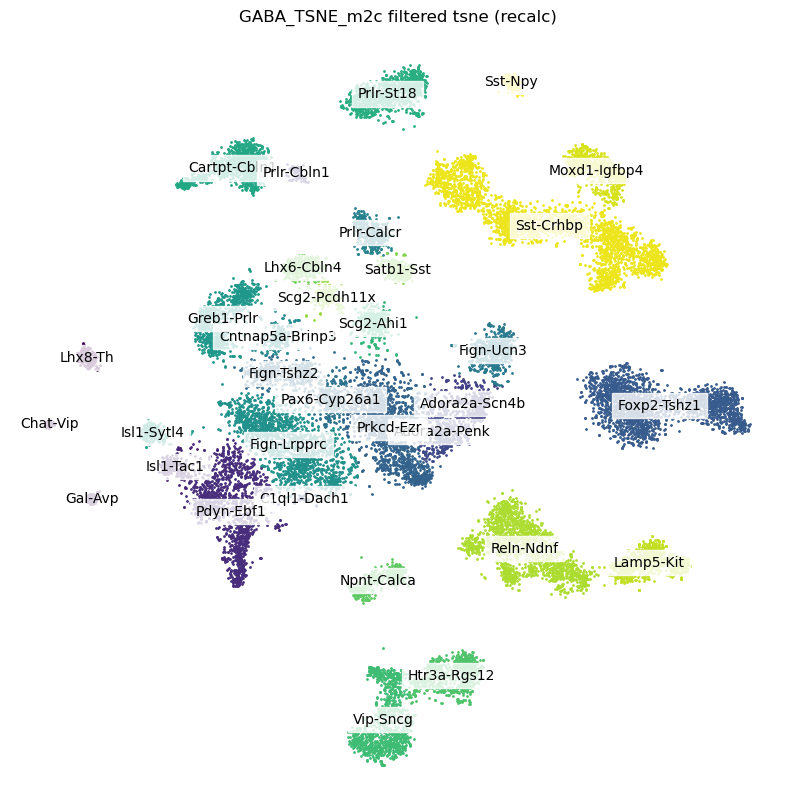

In [ ]:
#GABA_label_color_df = pd.read_excel(GABA_filtered_folder + 'GABA_filtered_labels_rc.xlsx')
GABA_m_2_c_dict = dict(zip(labels,colors))

dp.plot_rc_tsne(meta_data_df_plis_f,arr_df_sorted.loc[:,['tsne-1', 'tsne-2']].values,'GABA_TSNE_m2c', out_dir,m_2_c_dict = GABA_m_2_c_dict,savefig=True)

In [533]:
#Stacked bar plot showing number of cells from each dataset in each cluster
meta_data_df_plis_f

,AGCCAGCCAAATGCGG-1_19-1,TGTGGCGTCGGAATGG-1_19-1,CCTCAGTGTCGCGTTG-1_19-1,TGAATCGTCGCTATTT-1_19-1,GTTAGACAGAGAGTGA-1_19-1,TTGAGTGTCTGAGCAT-1_10X36_1,CATCCCATCGTGCGAC-1_19-1,GGGTGTCAGACAGTCG-1_10X38_1,AGACAGGGTGAGCAGT-1_19-1,CAGGTATCACTAGAGG-1_08-1,...,CCTCCAATCGCCTCTA-1_10X36_2,AATGGAATCTCGGGAC-1_10X51_2,TTGACCCAGCTCATAC-1_10X51_2,GCGGAAACAAAGTGTA-1_10X35_2,TGACGCGCAGTTGCGC-1_10X35_1,TGATTTCGTTTGCCGG-1_10X35_1,AGTAGTCGTTCTCTCG-1_10X36_1,CCGGGTAGTAGCTGAG-1_10X36_1,CTACCTGGTTCGGCGT-1_10X51_2,AGCGATTCACACGGTC-1_18-1
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA
SampleID,10X19_1,10X19_1,10X19_1,10X19_1,10X19_1,10X36_1,10X19_1,10X38_1,10X19_1,10X08_1,...,10X36_2,10X51_2,10X51_2,10X35_2,10X35_1,10X35_1,10X36_1,10X36_1,10X51_2,10X18_1
dataset,amy,amy,amy,amy,amy,sd,amy,sd,amy,amy,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,amy
Age,~7w,~7w,~7w,~7w,~7w,8.5w,~7w,9w,~7w,8.5w,...,8.5w,11-12w,11-12w,8w,8w,8w,8.5w,8.5w,11-12w,~8w
Group,2h,2h,2h,2h,2h,Naïve-M,2h,Naïve-F,2h,naïve,...,Naïve-M,Breeder-F,Breeder-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,2h
Sex,M,M,M,M,M,M,M,F,M,M,...,M,F,F,F,F,F,M,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,33,33,33,33,33,33,33,33,33,33
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy,Sst-Npy
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy,GABA-33-Sst-Npy


Violin plot

/tmp/ipykernel_841664/3565302718.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  gaba_violin_markers = pd.unique([x.split('-')[0] for x in labels])
/home/isaac/analysis/scRNA-seq/dimorph_processing.py:2058: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  markers = list(markers[np.sort(idx)])


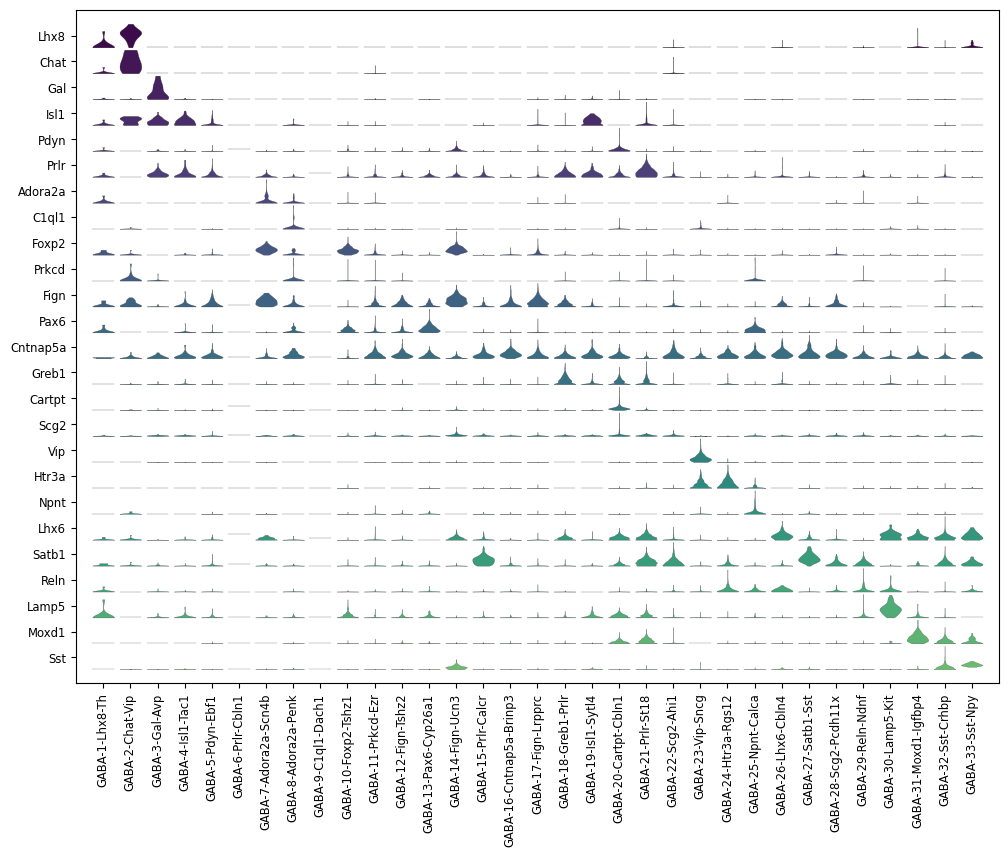

In [101]:
cell_class = 'GABA'
out_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
#get genes to be plotted using first gene of each label
labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
gaba_violin_markers = pd.unique([x.split('-')[0] for x in labels])

GABA_meta_data_df_plis_f_markers = pd.read_json(out_dir + str(cell_class) + 'meta_data_df_plis_f_markers_2025-06-05.json')

dp.marker_violin_plot(sd_df_orig,GABA_meta_data_df_plis_f_markers,'GABA',gaba_violin_markers,normalize=True, outfolder = out_dir)

In [548]:
out_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/GABA_l2_processed_eps_prc_80_minpts_30/'

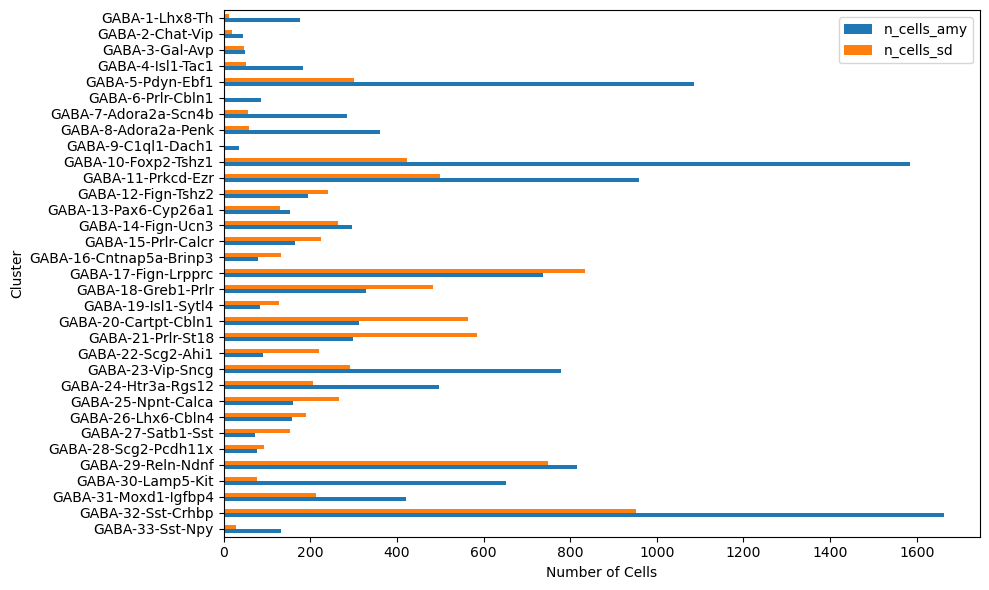

In [675]:
cell_class = 'GABA'
out_dir ='/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/'+ str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
gaba_cluster_dataset_df = dp_int.get_cells_per_dataset_per_cluster(meta_data_df_plis_f, out_dir, write_to_file=True)

In [552]:
gaba_cluster_dataset_df

,n_cells_amy,n_cells_sd
GABA-1-Lhx8-Th,175,12
GABA-2-Chat-Vip,45,20
GABA-3-Gal-Avp,48,46
GABA-4-Isl1-Tac1,184,51
GABA-5-Pdyn-Ebf1,1086,301
GABA-6-Prlr-Cbln1,86,1
GABA-7-Adora2a-Scn4b,285,57
GABA-8-Adora2a-Penk,360,59
GABA-9-C1ql1-Dach1,36,1
GABA-10-Foxp2-Tshz1,1584,422


# Vglut1

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/VGLUT1int_sID_dataset/'

In [554]:
#load/setup vglut1 files
cell_class = 'VGLUT1'
vglut1_convergence_test_dir = vglut1_iso_dir + str(cell_class) +'_convergence_test/data/'

vglut1_meta_data_df_pca = pd.read_json(vglut1_iso_dir +'meta_data_df_pca_union_'+str(cell_class)  +'.json')
vglut1_arr = np.load(vglut1_convergence_test_dir +  '10_iter_amy_sd_arr_tsne_union.npy')
vglut1_hm_arr = np.load(vglut1_convergence_test_dir +   '10_iter_amy_sd_hm_arr.npy')
vglut1_meta_data_df  = dp_int.enhance_metadata(vglut1_meta_data_df_pca,
                                            sd_metadata_path,
                                            amy_raw_md_path,
                                            vglut1_iso_dir,
                                            'meta_data_df_ags_' + str(cell_class),
                                            write_to_file=True)

In [555]:
vglut1_df = dp_int.initialize_expr_matrix(amy_df_orig,
                               sd_df_orig,
                               vglut1_meta_data_df,
                               sex_gene_list,
                               IEG_list,
                               vglut1_iso_dir)

removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']
removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib

column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00
params for dbscan
minpts:  30
epsilon percentile 80
epsilon:  1.9591967928737515



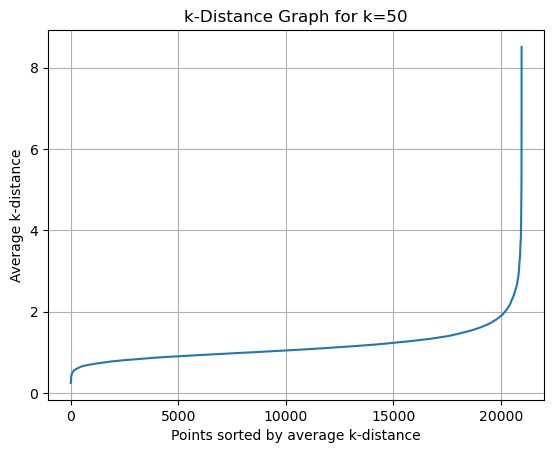

The knee is at x = 20259, y = 2.0473711973724034


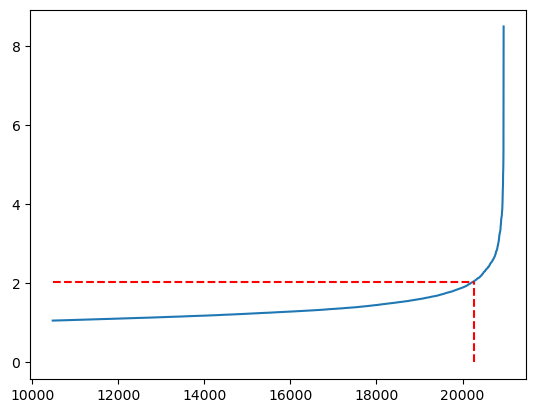

Optimal epsilon: 2.0473711973724034
running dbscan with epsilon: 1.9591967928737515  and minpts: 30
Estimated number of clusters: 17
Estimated number of noise points: 802


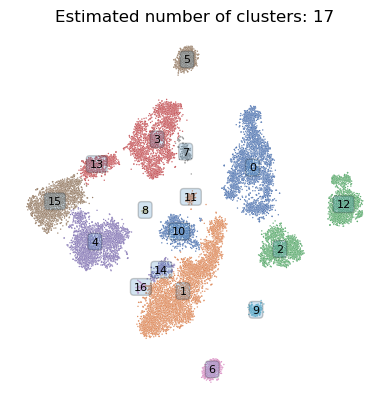

verify raw prelinkage df and raw metadata df have same columns:
True


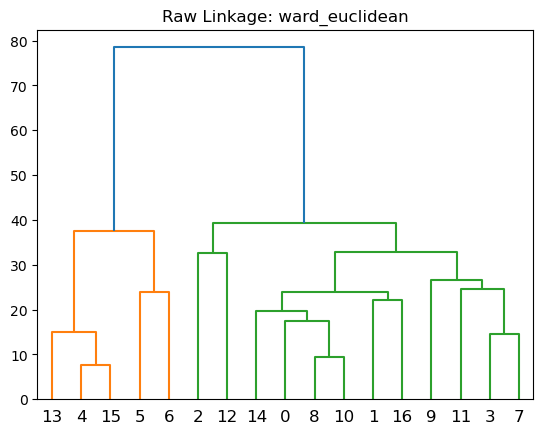

[ 6  5  4 15 13  1 16 10  8  0 14 11  3  7  9  2 12]


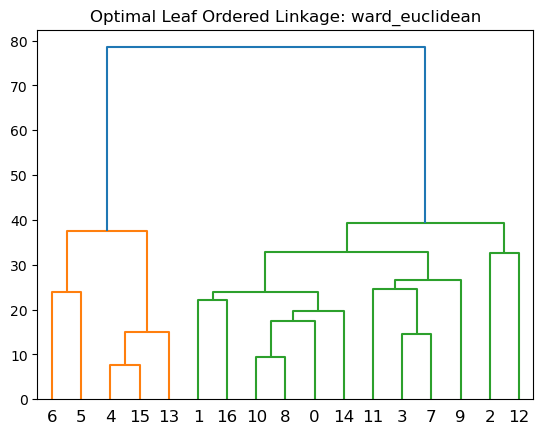

metadata df shape post inter cluster sort
(9, 20955)


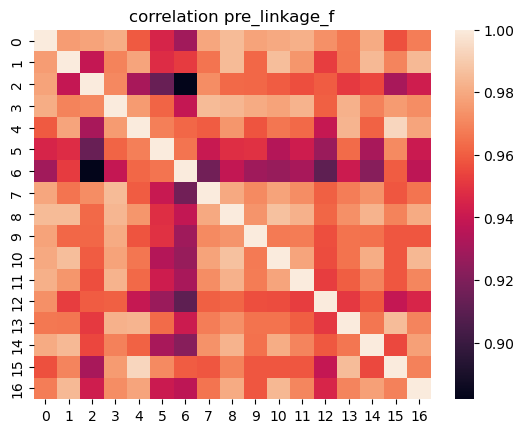

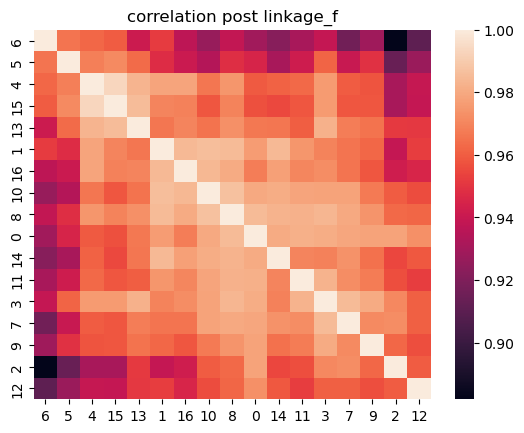

{6: 1, 5: 2, 4: 3, 15: 4, 13: 5, 1: 6, 16: 7, 10: 8, 8: 9, 0: 10, 14: 11, 11: 12, 3: 13, 7: 14, 9: 15, 2: 16, 12: 17}
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16]
check if df plis columns equal metadata df plis columns:
[ True  True  True ...  True  True  True]
len marker_Genes_sorted 120
len marker_genes_sorted_final 120
column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 547, 1236, 3568, 5507, 6245, 10379, 10427, 11339, 11399, 14601, 14881, 15007, 17477, 17701, 17971, 19435, 20954]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
17
[array([0, 1, 4, 5, 2, 3]), array([ 8, 19,  6, 12, 20, 11,  9, 10,  7]), array([17, 13, 14]), array([26, 24, 21, 25, 23, 22]), array([33, 31, 29, 32, 28, 30, 27]), array([40, 36, 34, 37, 38, 39]), array([18, 48, 46, 47, 49, 45, 15]), array([44, 42, 55, 56, 54, 53, 52, 51, 35]), array([57, 59, 60, 61, 58]), array([64, 65, 67, 62]), array([73, 75, 50, 16, 41, 74, 76, 77

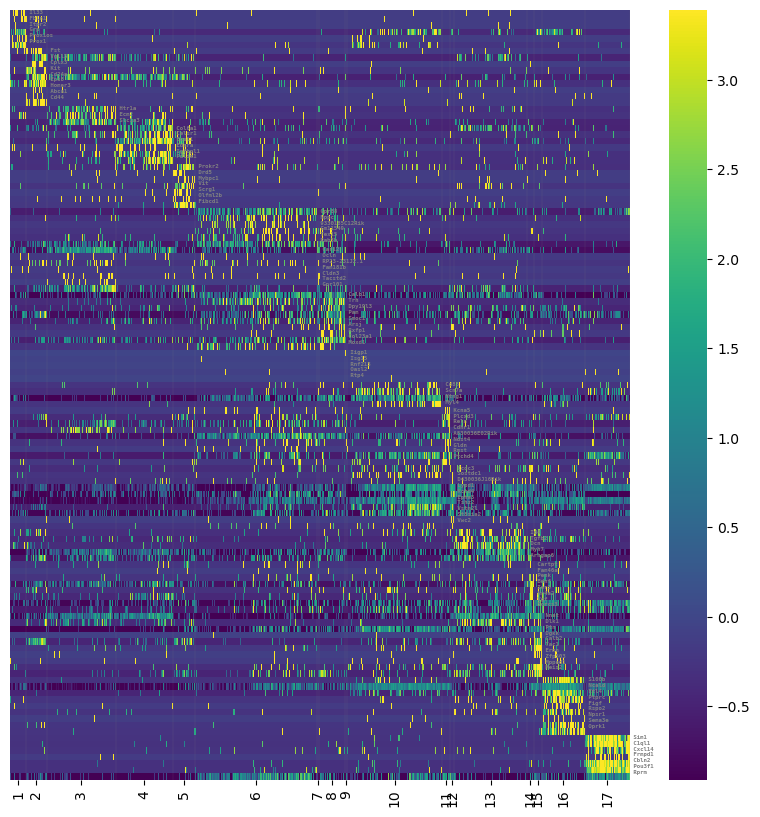

True


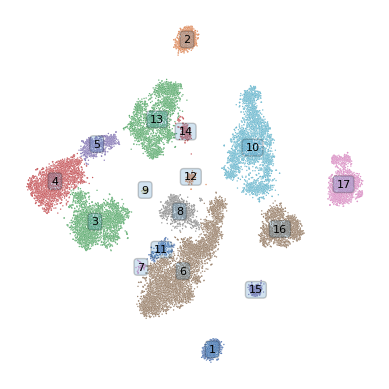

writing to file...


In [561]:
integrated_cell_types_dir = vglut1_iso_dir + 'integrated_cell_types/'
vglut1_df_marker, vglut1_arr_tsne, vglut1_meta_data_df_plis, vglut1_linkage_cluster_order, vglut1_df_marker_log_and_std_col, vglut1_df_plis, vglut1_cluster_indices, vglut1_df_marker_log_and_std, vglut1_pos, vglut1_tg, vglut1_tgfs, vglut1_change_indices, linkage_alg, dist_metric = dp_int.process(vglut1_df,vglut1_meta_data_df,vglut1_arr,str(cell_class),integrated_cell_types_dir,write_to_file=True)


In [562]:
out_dir ='/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/'+ str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'

In [563]:
cell_class

'VGLUT1'

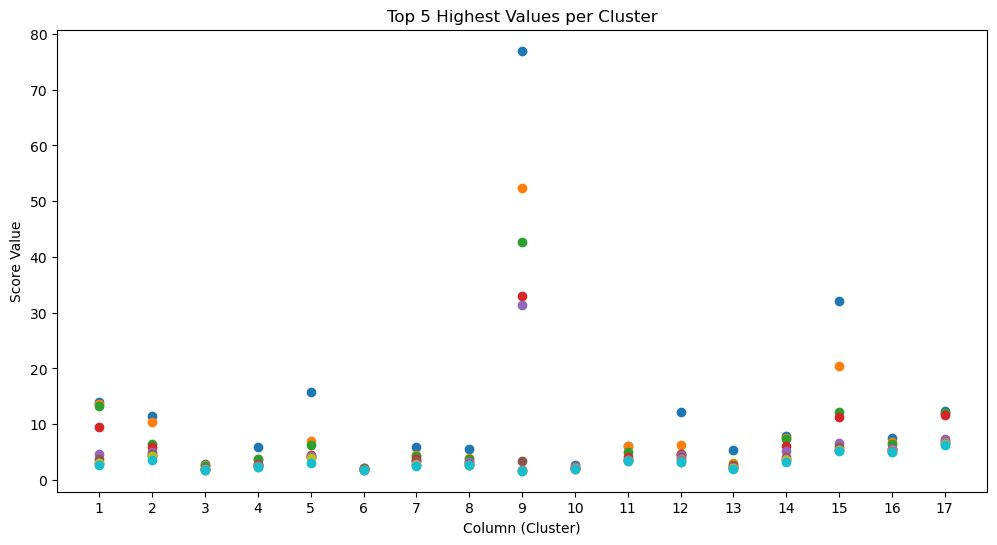

In [564]:
vglut1_top_genes, vglut1_top_values = dp.get_top_scores(out_dir, cell_class, top_n=10)

vglut1_int_marker_labels_df, vglut1_meta_data_df_int = dp.get_integrated_marker_names(vglut1_meta_data_df_plis,vglut1_top_genes,cell_class, out_dir,write_to_file=True)


In [569]:
vglut1_arr_df_sorted = pd.read_feather(out_dir + 'arr_df_sorted.feather')

vglut1_labels = np.array(vglut1_arr_df_sorted.loc[:,'labels'])

vglut1_df_tmp  = vglut1_df.reindex(columns = vglut1_meta_data_df_plis.columns)

column_sums = vglut1_df_tmp.loc[:,vglut1_df_tmp.columns].sum(axis=0)
vglut1_df_n = vglut1_df_tmp.div(column_sums)
#scale by norm_scale_factor
vglut1_df_n = vglut1_df_n.multiply(20000)

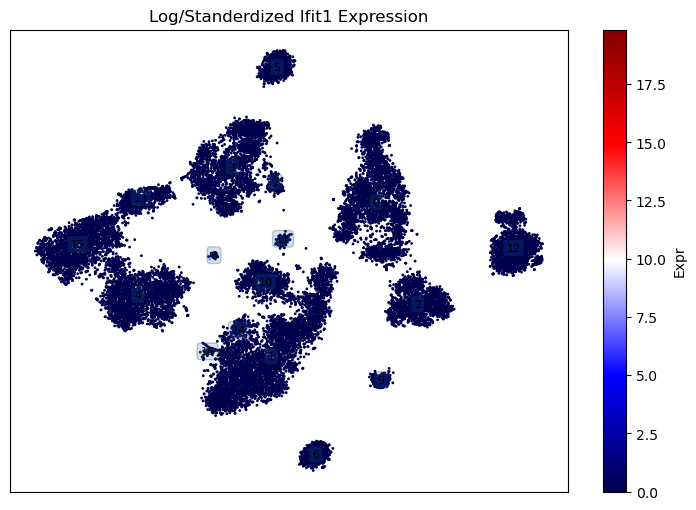

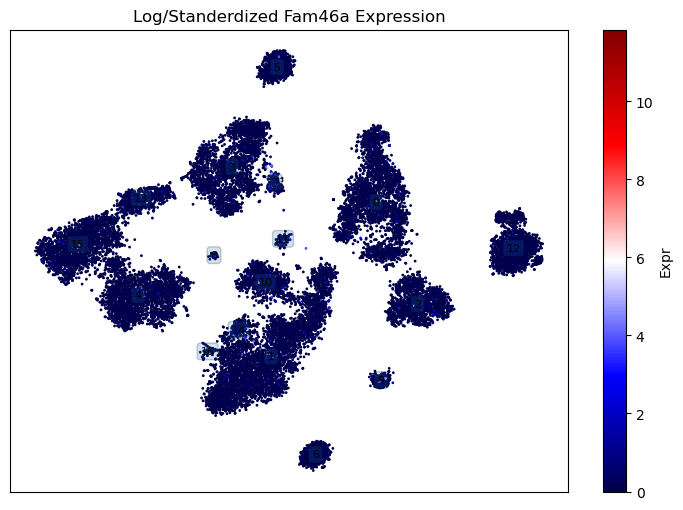

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1970: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  majority_markers.append(m)


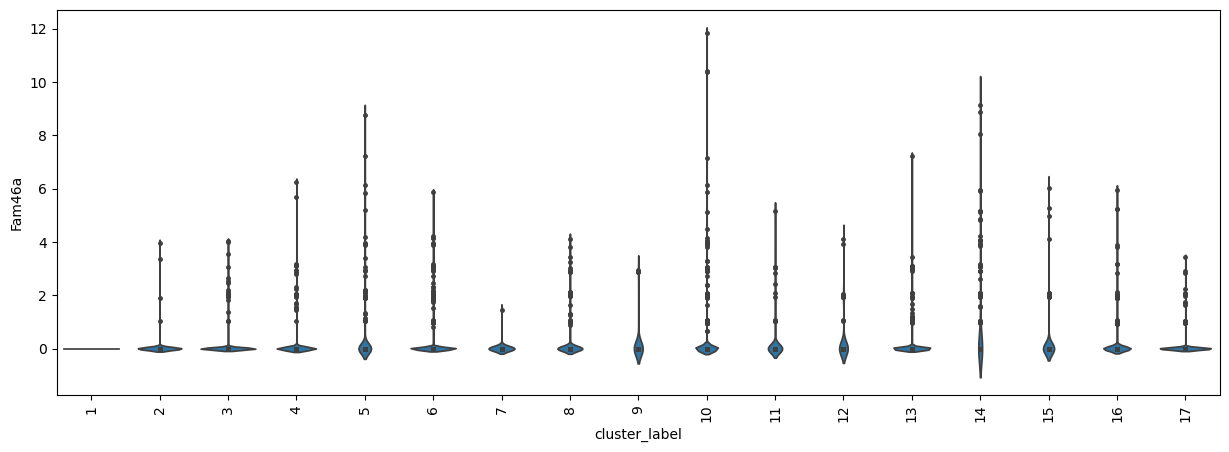

In [590]:
%matplotlib inline
gene = 'Fam46a'
dp.plot_marker_on_tsne(vglut1_arr_df_sorted, vglut1_df_n, gene, vglut1_labels)
dp.check_gene_cluster_expression(vglut1_df_n, vglut1_meta_data_df_plis, gene, vglut1_linkage_cluster_order)

In [591]:
vglut1_top_genes[13]

['Nr4a2',
 'Cartpt',
 'Bdnf',
 'Vgf',
 'Sorcs3',
 'Nnat',
 'Penk',
 'Acvr1c',
 'Ier3',
 'Fam46a']

In [611]:
vglut1_labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
vglut1_meta_data_df_plis_f = vglut1_meta_data_df_plis.copy()
vglut1_meta_data_df_plis_f = vglut1_meta_data_df_plis_f.drop('markers')
vglut1_meta_data_df_plis_f = vglut1_meta_data_df_plis_f.drop('full_name')
#make cell class row consistently upper case
vglut1_meta_data_df_plis_f.loc['cell_class',:] = vglut1_meta_data_df_plis_f.loc['cell_class',:].str.upper()
vglut1_meta_data_df_plis_f = dp.update_metadata_w_markers(out_dir,vglut1_meta_data_df_plis_f,vglut1_linkage_cluster_order, vglut1_labels, cell_class, write_to_file=True)

In [612]:
vglut1_meta_data_df_plis_f

,TCCGAAAAGCACTTTG-1_10X52_3,GTCTACCTCTTCGACC-1_10X52_3,ACCTGAATCGTAACAC-1_10X52_4,CACCGTTTCTACGCGG-1_10X52_4,GCTACAAGTGAATTGA-1_10X52_4,GGGACCTCACGCCACA-1_10X52_4,TAACGACTCTCCCTAG-1_10X52_4,CTCCAACCAACTACGT-1_10X52_4,GATCCCTTCTGCGTCT-1_10X52_4,GCAGCCAGTATGCTTG-1_10X52_4,...,GCAACCGGTTGTGTTG-1_76-1,TTTGACTGTGGTCAAG-1_76-2,TCGACGGCAATAAGGT-1_76-2,TACTGCCGTATGAAAC-1_76-2,CATCGTCCATCCTGTC-1_75-3,CGTCCATGTTGCGAAG-1_18-1,AATCGTGCAAAGCACG-1_18-1,GTCATCCTCCACACCT-1_18-1,CATACTTCATCTATCT-1_10-1,CTCCTTTCAGCTCCTT-1_18-1
cell_class,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,...,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1
SampleID,10X52_3,10X52_3,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,...,10X76_1,10X76_2,10X76_2,10X76_2,10X75_3,10X18_1,10X18_1,10X18_1,10X10_1,10X18_1
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,amy,amy,amy,amy,amy,amy,amy,amy,amy,amy
Age,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,...,8w,8w,8w,8w,8w,~8w,~8w,~8w,10w,~8w
Group,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,...,2h,2h,2h,2h,recall,2h,2h,2h,2h,2h
Sex,M,M,M,M,M,M,M,M,M,M,...,M,M,M,M,M,M,M,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,17,17,17,17,17,17,17,17,17,17
markers,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,...,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1
full_name,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,...,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1


In [596]:
fsw = dp.compute_fs_waterfall(vglut1_df_marker)
fsw

len marker gen sorted 120
fs 4.1


4.1

saving heatmap..


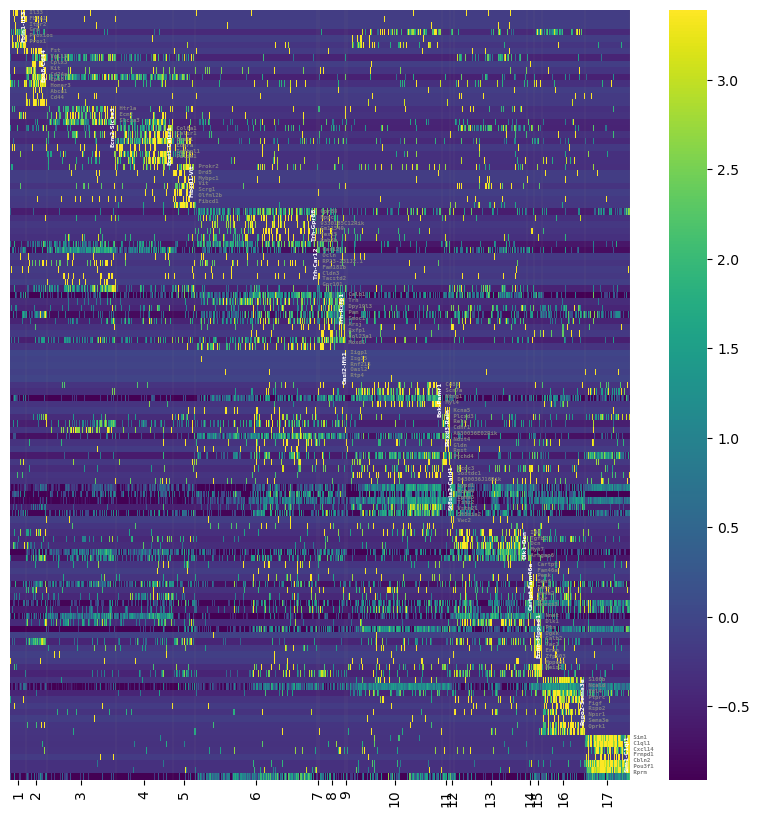

In [599]:
dp.plot_marker_heatmap(vglut1_df_marker_log_and_std_col, 
                       vglut1_pos, 
                       vglut1_linkage_cluster_order, 
                       vglut1_change_indices, 
                       vglut1_tg, 
                       vglut1_tgfs, 
                       linkage_alg,
                       dist_metric,
                       out_dir,
                       fs_waterfall = fsw,
                       cluster_labels = vglut1_labels,
                       savefig = True,
                       cell_class = str(cell_class) +'_labeled')

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1838: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.ylabel('tsne-2')


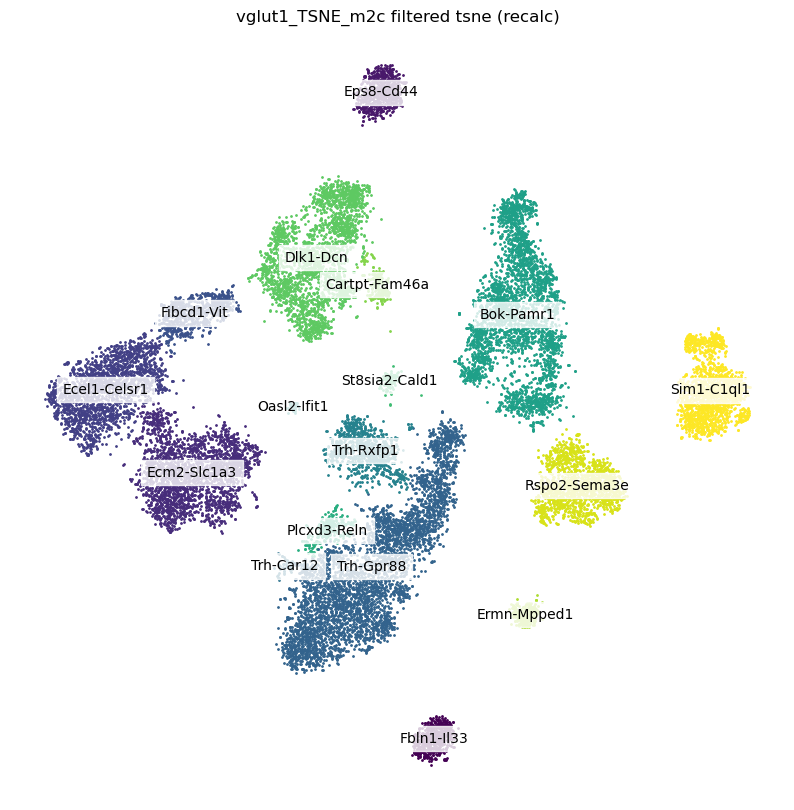

In [600]:
vglut1_colors = dp.get_discrete_colors_from_strings(vglut1_labels)

#vglut1_label_color_df = pd.read_excel(vglut1_filtered_folder + 'vglut1_filtered_labels_rc.xlsx')
vglut1_m_2_c_dict = dict(zip(vglut1_labels,vglut1_colors))

dp.plot_rc_tsne(vglut1_meta_data_df_plis_f,vglut1_arr_df_sorted.loc[:,['tsne-1', 'tsne-2']].values,'vglut1_TSNE_m2c', out_dir,m_2_c_dict = vglut1_m_2_c_dict,savefig=True)

Violin plot

/tmp/ipykernel_841664/249907249.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  vglut1_violin_markers = pd.unique([x.split('-')[0] for x in labels])
/home/isaac/analysis/scRNA-seq/dimorph_processing.py:2058: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  markers = list(markers[np.sort(idx)])


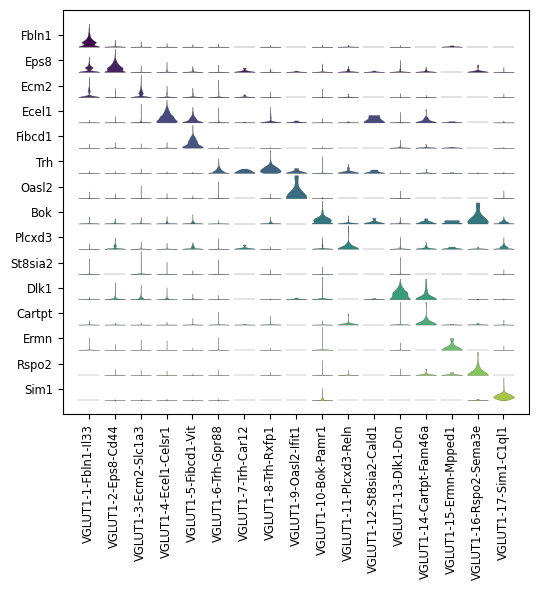

In [100]:
cell_class = 'VGLUT1'
out_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
#get genes to be plotted using first gene of each label
labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
vglut1_violin_markers = pd.unique([x.split('-')[0] for x in labels])

VGLUT1_meta_data_df_plis_f_markers = pd.read_json(out_dir + str(cell_class) + 'meta_data_df_plis_f_markers_2025-06-08.json')

dp.marker_violin_plot(sd_df_orig,VGLUT1_meta_data_df_plis_f_markers,'VGLUT1',vglut1_violin_markers,normalize=True, outfolder = out_dir)

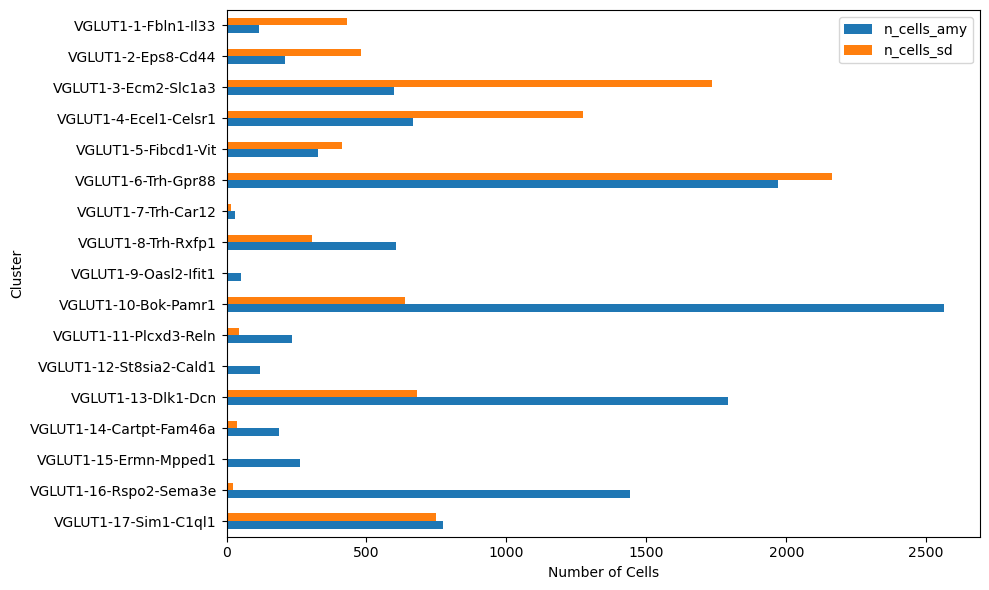

In [674]:
cell_class = 'VGLUT1'
out_dir ='/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/'+ str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
vglut1_cluster_dataset_df = dp_int.get_cells_per_dataset_per_cluster(vglut1_meta_data_df_plis_f, out_dir, write_to_file=True)

In [695]:
vglut1_meta_data_df_plis_f

,TCCGAAAAGCACTTTG-1_10X52_3,GTCTACCTCTTCGACC-1_10X52_3,ACCTGAATCGTAACAC-1_10X52_4,CACCGTTTCTACGCGG-1_10X52_4,GCTACAAGTGAATTGA-1_10X52_4,GGGACCTCACGCCACA-1_10X52_4,TAACGACTCTCCCTAG-1_10X52_4,CTCCAACCAACTACGT-1_10X52_4,GATCCCTTCTGCGTCT-1_10X52_4,GCAGCCAGTATGCTTG-1_10X52_4,...,GCAACCGGTTGTGTTG-1_76-1,TTTGACTGTGGTCAAG-1_76-2,TCGACGGCAATAAGGT-1_76-2,TACTGCCGTATGAAAC-1_76-2,CATCGTCCATCCTGTC-1_75-3,CGTCCATGTTGCGAAG-1_18-1,AATCGTGCAAAGCACG-1_18-1,GTCATCCTCCACACCT-1_18-1,CATACTTCATCTATCT-1_10-1,CTCCTTTCAGCTCCTT-1_18-1
cell_class,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,...,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1,VGLUT1
SampleID,10X52_3,10X52_3,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,10X52_4,...,10X76_1,10X76_2,10X76_2,10X76_2,10X75_3,10X18_1,10X18_1,10X18_1,10X10_1,10X18_1
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,amy,amy,amy,amy,amy,amy,amy,amy,amy,amy
Age,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,11-12w,...,8w,8w,8w,8w,8w,~8w,~8w,~8w,10w,~8w
Group,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,Breeder-M,...,2h,2h,2h,2h,recall,2h,2h,2h,2h,2h
Sex,M,M,M,M,M,M,M,M,M,M,...,M,M,M,M,M,M,M,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,17,17,17,17,17,17,17,17,17,17
markers,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,Fbln1-Il33,...,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1,Sim1-C1ql1
full_name,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,VGLUT1-1-Fbln1-Il33,...,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1,VGLUT1-17-Sim1-C1ql1


In [699]:
tmp = vglut1_meta_data_df_plis_f.loc[:,vglut1_meta_data_df_plis_f.loc['full_name',:] == 'VGLUT1-17-Sim1-C1ql1']

In [704]:
Counter(tmp.loc['Group',tmp.loc['dataset',:] == 'amy'])

Counter({'2h': 237, 'naïve': 162, '24h': 141, 'recall': 134, '8h': 99})

# VGLUT2

removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']
removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib

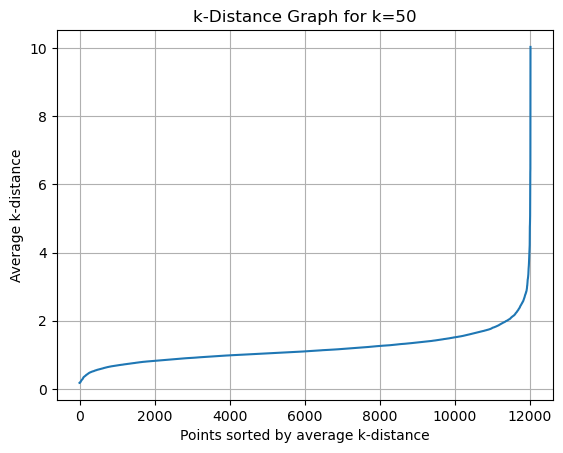

The knee is at x = 11607, y = 2.191491898146477


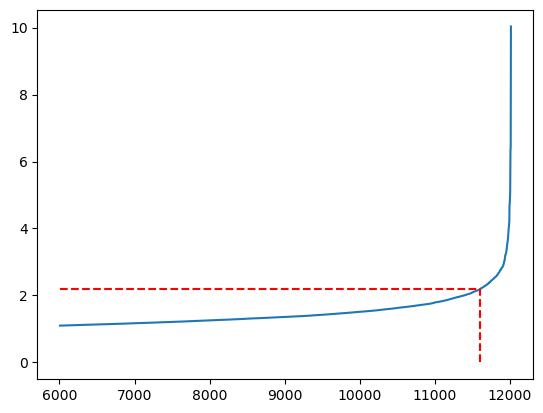

Optimal epsilon: 2.191491898146477
running dbscan with epsilon: 2.1067051324414625  and minpts: 30
Estimated number of clusters: 26
Estimated number of noise points: 485


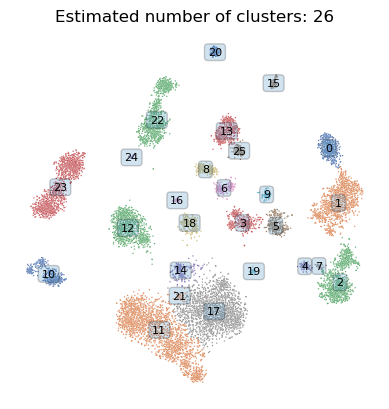

verify raw prelinkage df and raw metadata df have same columns:
True


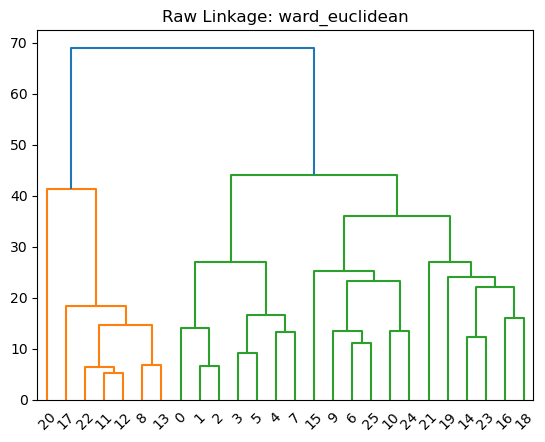

[20 13  8 22 12 11 17 15  6 25  9 10 24 19 16 18 14 23 21  7  4  3  5  2
  1  0]


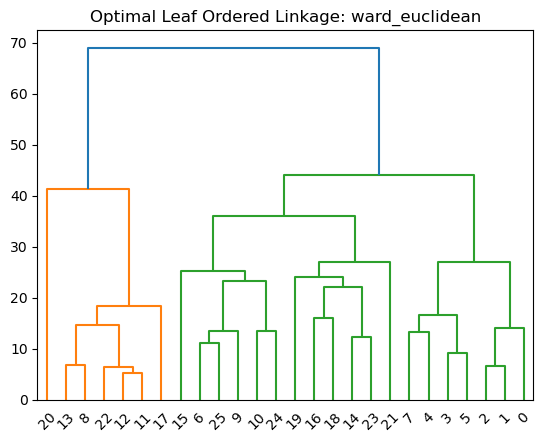

metadata df shape post inter cluster sort
(9, 12014)


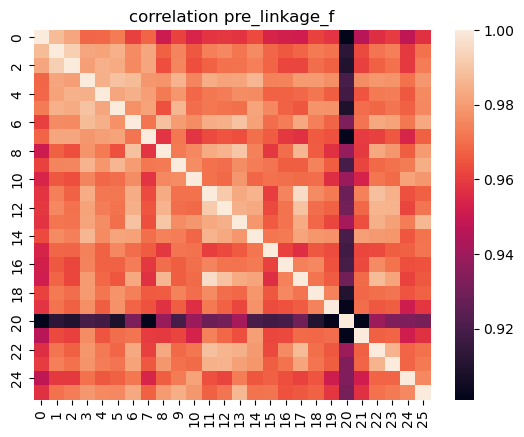

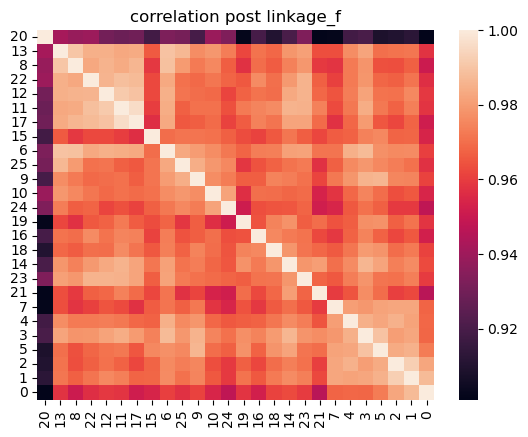

{20: 1, 13: 2, 8: 3, 22: 4, 12: 5, 11: 6, 17: 7, 15: 8, 6: 9, 25: 10, 9: 11, 10: 12, 24: 13, 19: 14, 16: 15, 18: 16, 14: 17, 23: 18, 21: 19, 7: 20, 4: 21, 3: 22, 5: 23, 2: 24, 1: 25, 0: 26}
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
check if df plis columns equal metadata df plis columns:
[ True  True  True ...  True  True  True]
len marker_Genes_sorted 163
len marker_genes_sorted_final 163
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 126, 546, 750, 1659, 2506, 4429, 6117, 6235, 6430, 6562, 6655, 7083, 7119, 7173, 7211, 7468, 7687, 8764, 8800, 8837, 8930, 9295, 9626, 10511, 11599, 12013]
[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
25
[array([  0,  26,   2,   1, 117,   6,   4,   3,  10]), array([11,  8,  9, 29, 12]), array([19, 17, 16]), array([21, 23, 24]), array([30, 31, 27]), array([35, 39, 36]), array([137,  32,  53, 153,  

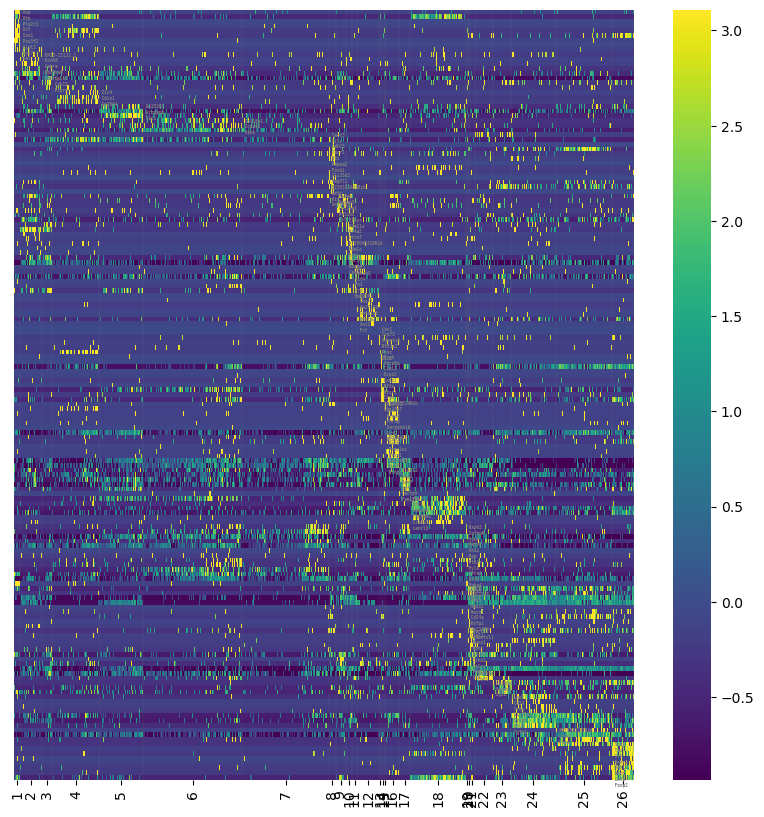

True


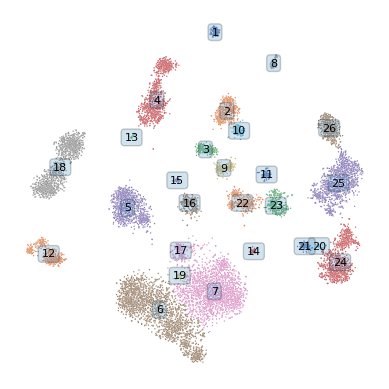

writing to file...


In [616]:
cell_class = 'VGLUT2'
vglut2_convergence_test_dir = vglut2_iso_dir + str(cell_class) +'_convergence_test/data/'

vglut2_meta_data_df_pca = pd.read_json(vglut2_iso_dir +'meta_data_df_pca_union_'+str(cell_class)  +'.json')
vglut2_arr = np.load(vglut2_convergence_test_dir +  '6_iter_amy_sd_arr_tsne_union.npy')
vglut2_hm_arr = np.load(vglut2_convergence_test_dir +   '6_iter_amy_sd_hm_arr.npy')
vglut2_meta_data_df  = dp_int.enhance_metadata(vglut2_meta_data_df_pca,
                                            sd_metadata_path,
                                            amy_raw_md_path,
                                            vglut2_iso_dir,
                                            'meta_data_df_ags_' + str(cell_class),
                                            write_to_file=True)

vglut2_df = dp_int.initialize_expr_matrix(amy_df_orig,
                               sd_df_orig,
                               vglut2_meta_data_df,
                               sex_gene_list,
                               IEG_list,
                               vglut2_iso_dir)

integrated_cell_types_dir = vglut2_iso_dir + 'integrated_cell_types/'
vglut2_df_marker, vglut2_arr_tsne, vglut2_meta_data_df_plis, vglut2_linkage_cluster_order, vglut2_df_marker_log_and_std_col, vglut2_df_plis, vglut2_cluster_indices, vglut2_df_marker_log_and_std, vglut2_pos, vglut2_tg, vglut2_tgfs, vglut2_change_indices, linkage_alg, dist_metric = dp_int.process(vglut2_df,vglut2_meta_data_df,vglut2_arr,str(cell_class),integrated_cell_types_dir,write_to_file=True)


saving heatmap..


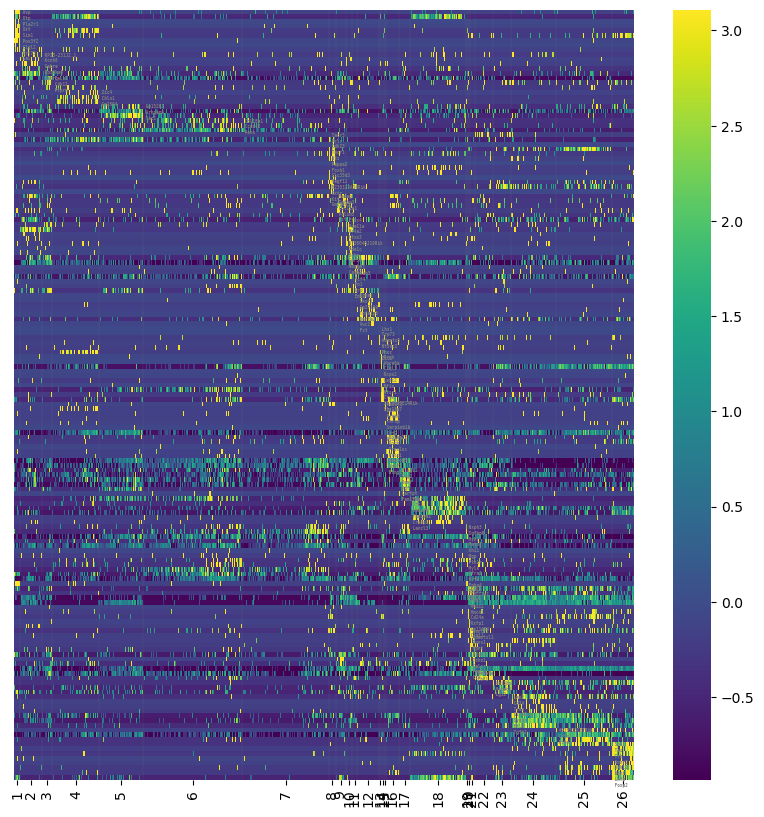

In [617]:
#tweak fsw size as needed
out_dir = integrated_cell_types_dir + str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
os.makedirs(out_dir, exist_ok=True)

fsw = 3.1
dp.plot_marker_heatmap(vglut2_df_marker_log_and_std_col, 
                    vglut2_pos, 
                    vglut2_linkage_cluster_order, 
                    vglut2_change_indices, 
                    vglut2_tg, 
                    vglut2_tgfs, 
                    linkage_alg,
                    dist_metric,
                    out_dir,
                    fs_waterfall = fsw,
                    savefig = True,
                    cell_class = str(cell_class))

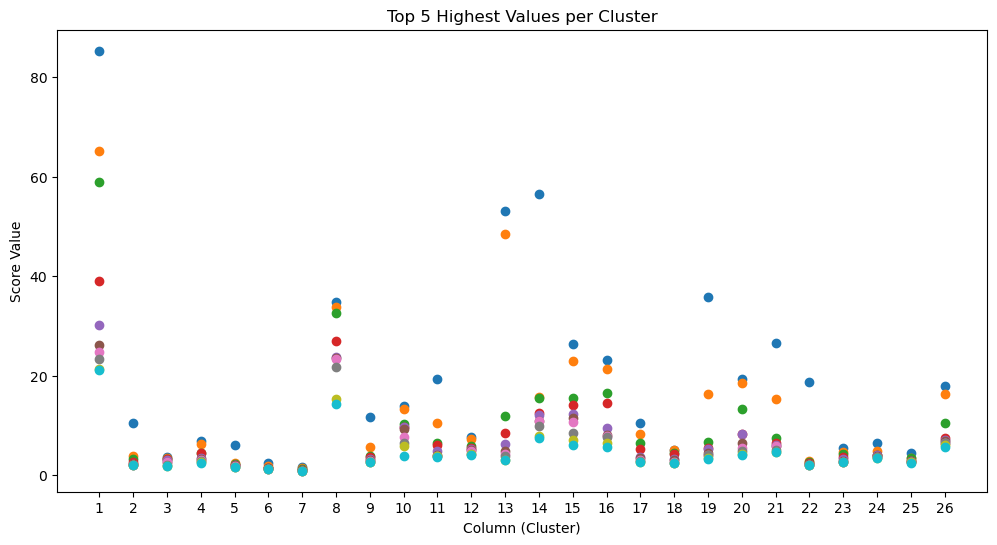

In [618]:
out_dir ='/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/'+ str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'

vglut2_top_genes, vglut2_top_values = dp.get_top_scores(out_dir, cell_class, top_n=10)

vglut2_int_marker_labels_df, vglut2_meta_data_df_int = dp.get_integrated_marker_names(vglut2_meta_data_df_plis,vglut2_top_genes,cell_class, out_dir,write_to_file=True)

vglut2_arr_df_sorted = pd.read_feather(out_dir + 'arr_df_sorted.feather')

vglut2_labels = np.array(vglut2_arr_df_sorted.loc[:,'labels'])

vglut2_df_tmp  = vglut2_df.reindex(columns = vglut2_meta_data_df_plis.columns)

column_sums = vglut2_df_tmp.loc[:,vglut2_df_tmp.columns].sum(axis=0)
vglut2_df_n = vglut2_df_tmp.div(column_sums)
#scale by norm_scale_factor
vglut2_df_n = vglut2_df_n.multiply(20000)

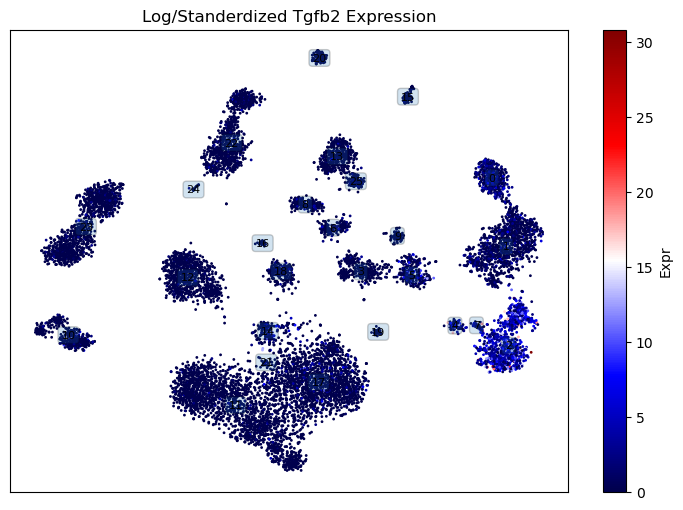

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1970: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  majority_markers.append(m)


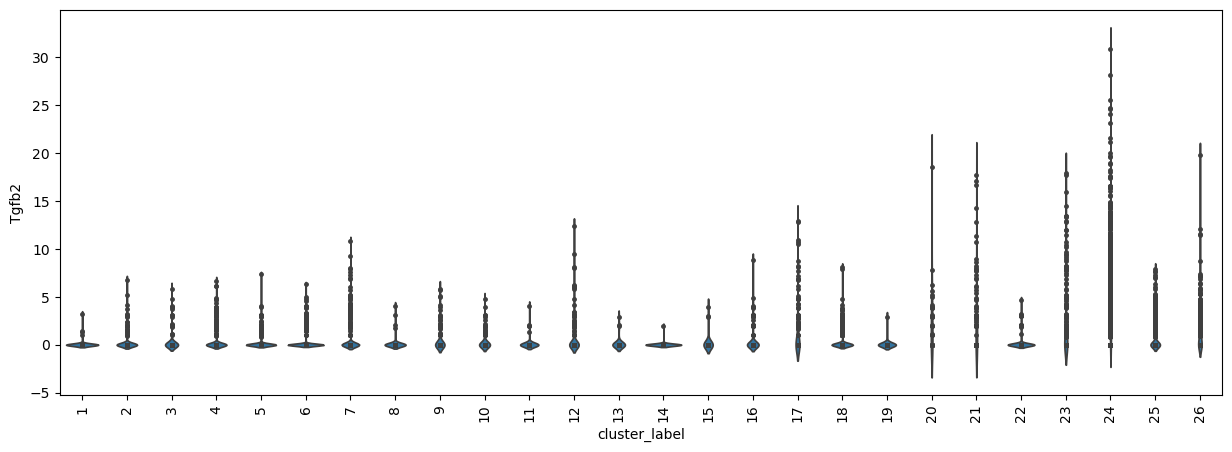

In [645]:
%matplotlib inline
gene = 'Tgfb2'
dp.plot_marker_on_tsne(vglut2_arr_df_sorted, vglut2_df_n, gene, vglut2_labels)
dp.check_gene_cluster_expression(vglut2_df_n, vglut2_meta_data_df_plis, gene, vglut2_linkage_cluster_order)


In [705]:
out_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/GABA_l2_processed_eps_prc_80_minpts_30/'

In [706]:
cell_class = 'VGLUT2'
out_dir ='/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/'+ str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'

vglut2_labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
vglut2_meta_data_df_plis_f = vglut2_meta_data_df_plis.copy()
vglut2_meta_data_df_plis_f = vglut2_meta_data_df_plis_f.drop('markers')
vglut2_meta_data_df_plis_f = vglut2_meta_data_df_plis_f.drop('full_name')
vglut2_meta_data_df_plis_f.loc['cell_class',:] = vglut2_meta_data_df_plis_f.loc['cell_class',:].str.upper()
vglut2_meta_data_df_plis_f = dp.update_metadata_w_markers(out_dir,vglut2_meta_data_df_plis_f,vglut2_linkage_cluster_order, vglut2_labels, cell_class, write_to_file=True)


saving heatmap..


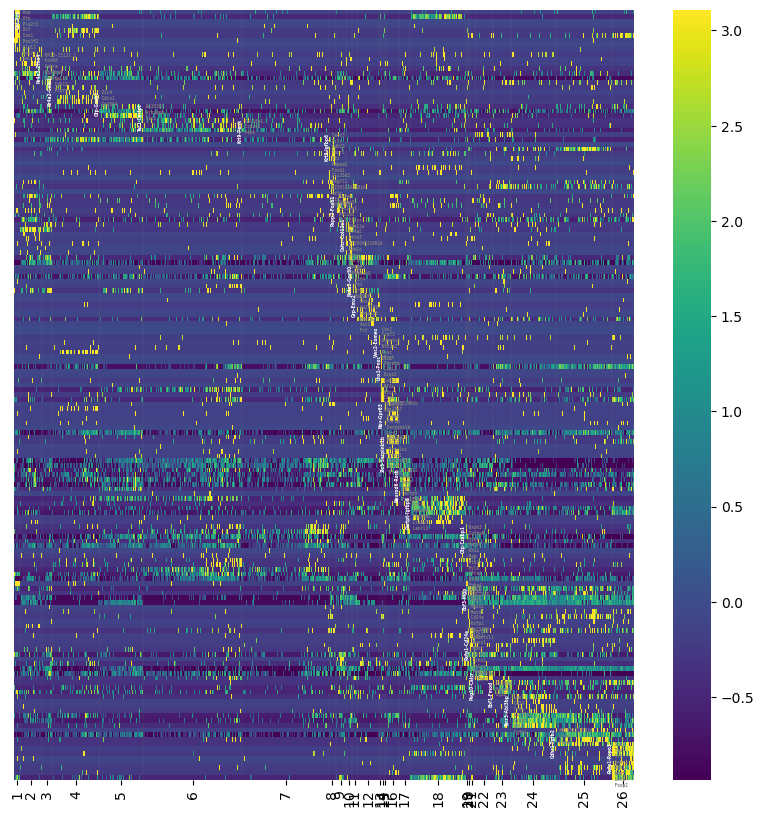

In [650]:
dp.plot_marker_heatmap(vglut2_df_marker_log_and_std_col, 
                       vglut2_pos, 
                       vglut2_linkage_cluster_order, 
                       vglut2_change_indices, 
                       vglut2_tg, 
                       vglut2_tgfs, 
                       linkage_alg,
                       dist_metric,
                       out_dir,
                       fs_waterfall = fsw,
                       cluster_labels = vglut2_labels,
                       savefig = True,
                       cell_class = str(cell_class) +'_labeled')

/home/isaac/analysis/scRNA-seq/dimorph_processing.py:1838: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x = 'tsne-1',y = 'tsne-2', data=grp, label=n, s = 1, c = m_2_c_dict[str(n)])


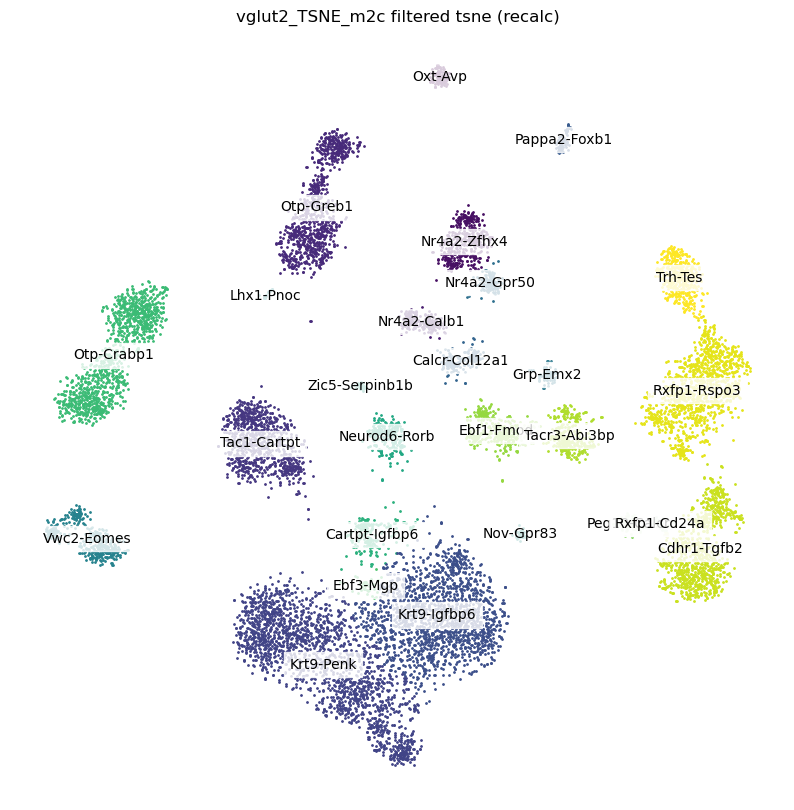

In [709]:
vglut2_colors = dp.get_discrete_colors_from_strings(vglut2_labels)

#vglut2_label_color_df = pd.read_excel(vglut2_filtered_folder + 'vglut2_filtered_labels_rc.xlsx')
vglut2_m_2_c_dict = dict(zip(vglut2_labels,vglut2_colors))

dp.plot_rc_tsne(vglut2_meta_data_df_plis_f,vglut2_arr_df_sorted.loc[:,['tsne-1', 'tsne-2']].values,'vglut2_TSNE_m2c', out_dir,m_2_c_dict = vglut2_m_2_c_dict,savefig=True)

/tmp/ipykernel_841664/2375392507.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  VGLUT2_violin_markers = pd.unique([x.split('-')[0] for x in labels])
/home/isaac/analysis/scRNA-seq/dimorph_processing.py:2058: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  markers = list(markers[np.sort(idx)])


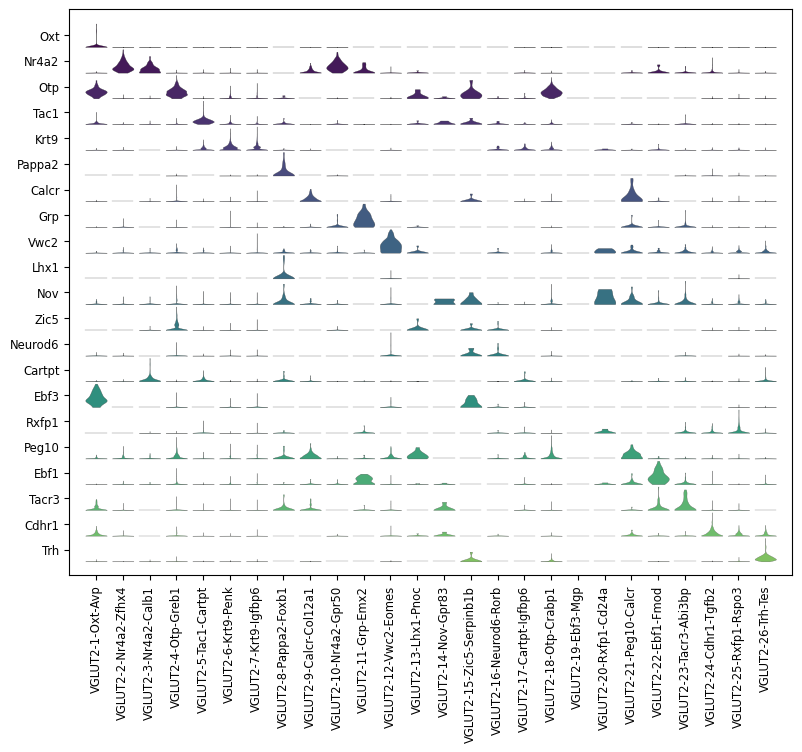

In [99]:
cell_class = 'VGLUT2'
out_dir = '/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + str(cell_class) + 'int_sID_dataset/integrated_cell_types/'+ str(cell_class) + '_l2_processed_eps_prc_80_minpts_30/'
#get genes to be plotted using first gene of each label
labels = dp.get_cluster_labels(out_dir, str(cell_class)+'_int_marker_labels.csv')
VGLUT2_violin_markers = pd.unique([x.split('-')[0] for x in labels])

VGLUT2_meta_data_df_plis_f_markers = pd.read_json(out_dir + str(cell_class) + 'meta_data_df_plis_f_markers_2025-06-08.json')

dp.marker_violin_plot(sd_df_orig,VGLUT2_meta_data_df_plis_f_markers,'VGLUT2',VGLUT2_violin_markers,normalize=True, outfolder = out_dir)

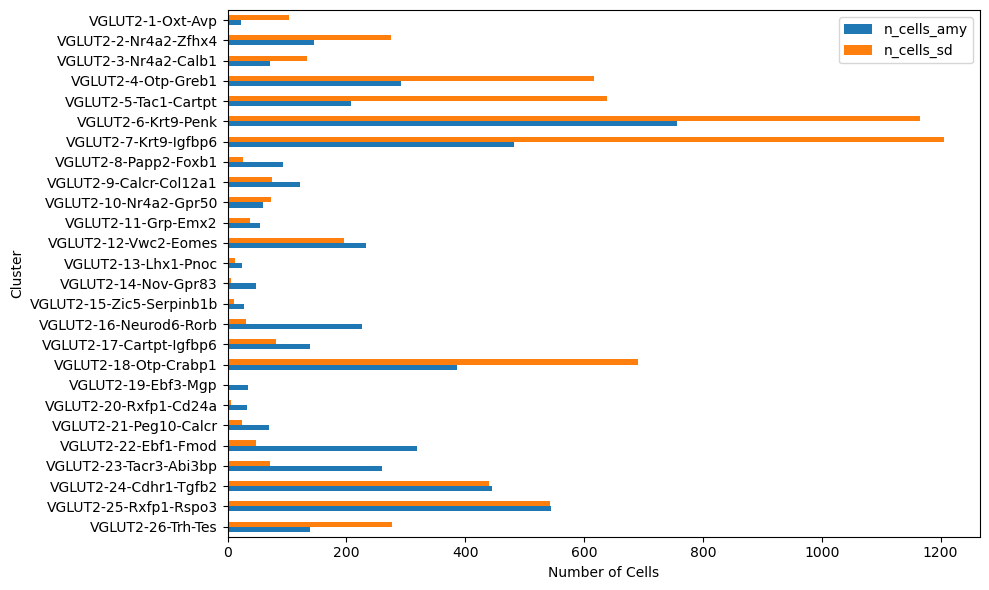

In [673]:
vglut2_cluster_dataset_df = dp_int.get_cells_per_dataset_per_cluster(vglut2_meta_data_df_plis_f, out_dir, write_to_file=True)

Concatenate metadata for each class into single, integrated dataframe

In [676]:
pd.concat([meta_data_df_plis_f,vglut1_meta_data_df_plis_f,vglut2_meta_data_df_plis_f], axis=1)

,AGCCAGCCAAATGCGG-1_19-1,TGTGGCGTCGGAATGG-1_19-1,CCTCAGTGTCGCGTTG-1_19-1,TGAATCGTCGCTATTT-1_19-1,GTTAGACAGAGAGTGA-1_19-1,TTGAGTGTCTGAGCAT-1_10X36_1,CATCCCATCGTGCGAC-1_19-1,GGGTGTCAGACAGTCG-1_10X38_1,AGACAGGGTGAGCAGT-1_19-1,CAGGTATCACTAGAGG-1_08-1,...,GAATCACCACAACGTT-1_10X36_1,GGCACGTGTTGCCGAC-1_10X51_2,CTATCCGCAACTGTGT-1_45-1,CAGCCAGCAGCTAACT-1_45-1,GTTCGCTCAACCCTCT-1_10X51_2,ATCATTCTCTACCACC-1_41-1,CCTCAGTCATGAATCC-1_10X51_2,AGGGCCTTCAGCAGAG-1_42-1,GGATCTACACAACCGC-1_42-1,TACGCTCTCGCTCTAC-1_42-1
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2
SampleID,10X19_1,10X19_1,10X19_1,10X19_1,10X19_1,10X36_1,10X19_1,10X38_1,10X19_1,10X08_1,...,10X36_1,10X51_2,10X45_1,10X45_1,10X51_2,10X41_1,10X51_2,10X42_1,10X42_1,10X42_1
dataset,amy,amy,amy,amy,amy,sd,amy,sd,amy,amy,...,sd,sd,amy,amy,sd,amy,sd,amy,amy,amy
Age,~7w,~7w,~7w,~7w,~7w,8.5w,~7w,9w,~7w,8.5w,...,8.5w,11-12w,9w,9w,11-12w,9.5w,11-12w,11.5w,11.5w,11.5w
Group,2h,2h,2h,2h,2h,Naïve-M,2h,Naïve-F,2h,naïve,...,Naïve-M,Breeder-F,24h,24h,Breeder-F,24h,Breeder-F,8h,8h,8h
Sex,M,M,M,M,M,M,M,F,M,M,...,M,F,M,M,F,M,F,M,M,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,26,26,26,26,26,26,26,26,26,26
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes


In [677]:
out_dir

'/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/GABAint_sID_dataset/integrated_cell_types/GABA_l2_processed_eps_prc_80_minpts_30/'

In [710]:
metadata_df_gabaglut_int = pd.concat([meta_data_df_plis_f,vglut1_meta_data_df_plis_f,vglut2_meta_data_df_plis_f], axis=1)
metadata_df_gabaglut_int.to_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + 'metadata_df_gabaglut_int.json')

In [711]:
metadata_df_gabaglut_int_sd = metadata_df_gabaglut_int.loc[:,metadata_df_gabaglut_int.loc['dataset',:] == 'sd']


In [712]:
metadata_df_gabaglut_int_sd

,TTGAGTGTCTGAGCAT-1_10X36_1,GGGTGTCAGACAGTCG-1_10X38_1,AGAGAATGTATTGCCA-1_10X51_2,AGACACTTCTGAGGTT-1_10X36_1,ATTCCTAAGTACTGGG-1_10X37_2,TCATGCCGTTGACTGT-1_10X36_1,AGGTAGGCAAGCCATT-1_10X52_2,CCCATTGAGATACATG-1_10X38_1,GAGTGAGAGTTTGAGA-1_10X35_1,CAGCCAGCAACCAATC-1_10X35_1,...,CTCAGGGCAAAGCACG-1_10X38_2,ACTTATCCACACGTGC-1_10X38_2,GCATGATTCATCTCTA-1_10X38_2,ACTATTCCAACACGTT-1_10X38_2,CTGTACCCAAGTAGTA-1_10X38_2,GAGACTTTCCATCTAT-1_10X37_1,GAATCACCACAACGTT-1_10X36_1,GGCACGTGTTGCCGAC-1_10X51_2,GTTCGCTCAACCCTCT-1_10X51_2,CCTCAGTCATGAATCC-1_10X51_2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2
SampleID,10X36_1,10X38_1,10X51_2,10X36_1,10X37_2,10X36_1,10X52_2,10X38_1,10X35_1,10X35_1,...,10X38_2,10X38_2,10X38_2,10X38_2,10X38_2,10X37_1,10X36_1,10X51_2,10X51_2,10X51_2
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,9w,11-12w,8.5w,8.5w,8.5w,11-12w,9w,8w,8w,...,9w,9w,9w,9w,9w,8.5w,8.5w,11-12w,11-12w,11-12w
Group,Naïve-M,Naïve-F,Breeder-F,Naïve-M,Naïve-M,Naïve-M,Breeder-F,Naïve-F,Naïve-F,Naïve-F,...,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,Breeder-F,Breeder-F
Sex,M,F,F,M,M,M,F,F,F,F,...,F,F,F,F,F,M,M,F,F,F
cluster_label,1,1,1,1,1,1,1,1,1,1,...,26,26,26,26,26,26,26,26,26,26
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes


In [713]:
metadata_df_gabaglut_int_sd.to_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + 'metadata_df_gabaglut_int_sd.json')

In [714]:
metadata_df_gabaglut_int_amy = metadata_df_gabaglut_int.loc[:,metadata_df_gabaglut_int.loc['dataset',:] == 'amy']
metadata_df_gabaglut_int_amy.to_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + 'metadata_df_gabaglut_int_amy.json')

In [2]:
metadata_df_gabaglut_int_sd = pd.read_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + 'metadata_df_gabaglut_int_sd.json')
tmp = pd.read_json('/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name2025-04-14.json')

In [4]:
metadata_df_gabaglut_int_sd

,TTGAGTGTCTGAGCAT-1_10X36_1,GGGTGTCAGACAGTCG-1_10X38_1,AGAGAATGTATTGCCA-1_10X51_2,AGACACTTCTGAGGTT-1_10X36_1,ATTCCTAAGTACTGGG-1_10X37_2,TCATGCCGTTGACTGT-1_10X36_1,AGGTAGGCAAGCCATT-1_10X52_2,CCCATTGAGATACATG-1_10X38_1,GAGTGAGAGTTTGAGA-1_10X35_1,CAGCCAGCAACCAATC-1_10X35_1,...,CTCAGGGCAAAGCACG-1_10X38_2,ACTTATCCACACGTGC-1_10X38_2,GCATGATTCATCTCTA-1_10X38_2,ACTATTCCAACACGTT-1_10X38_2,CTGTACCCAAGTAGTA-1_10X38_2,GAGACTTTCCATCTAT-1_10X37_1,GAATCACCACAACGTT-1_10X36_1,GGCACGTGTTGCCGAC-1_10X51_2,GTTCGCTCAACCCTCT-1_10X51_2,CCTCAGTCATGAATCC-1_10X51_2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2
SampleID,10X36_1,10X38_1,10X51_2,10X36_1,10X37_2,10X36_1,10X52_2,10X38_1,10X35_1,10X35_1,...,10X38_2,10X38_2,10X38_2,10X38_2,10X38_2,10X37_1,10X36_1,10X51_2,10X51_2,10X51_2
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,9w,11-12w,8.5w,8.5w,8.5w,11-12w,9w,8w,8w,...,9w,9w,9w,9w,9w,8.5w,8.5w,11-12w,11-12w,11-12w
Group,Naïve-M,Naïve-F,Breeder-F,Naïve-M,Naïve-M,Naïve-M,Breeder-F,Naïve-F,Naïve-F,Naïve-F,...,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,Breeder-F,Breeder-F
Sex,M,F,F,M,M,M,F,F,F,F,...,F,F,F,F,F,M,M,F,F,F
cluster_label,1,1,1,1,1,1,1,1,1,1,...,26,26,26,26,26,26,26,26,26,26
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes


In [7]:
row_name = 'dataset'
row_value = 'sd'
tmp.loc[row_name] = [row_value] * tmp.shape[1]

In [10]:
tmp = tmp.loc[metadata_df_gabaglut_int_sd.index, :]

In [14]:
tmp.shape

(9, 36707)

In [15]:
tmp = tmp.loc[:,tmp.loc['cell_class'] == 'Nonneuronal']

In [16]:
metadata_df_gabaglutnn_int_sd = pd.concat([metadata_df_gabaglut_int_sd, tmp], axis=1)
metadata_df_gabaglutnn_int_sd

,TTGAGTGTCTGAGCAT-1_10X36_1,GGGTGTCAGACAGTCG-1_10X38_1,AGAGAATGTATTGCCA-1_10X51_2,AGACACTTCTGAGGTT-1_10X36_1,ATTCCTAAGTACTGGG-1_10X37_2,TCATGCCGTTGACTGT-1_10X36_1,AGGTAGGCAAGCCATT-1_10X52_2,CCCATTGAGATACATG-1_10X38_1,GAGTGAGAGTTTGAGA-1_10X35_1,CAGCCAGCAACCAATC-1_10X35_1,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal
SampleID,10X36_1,10X38_1,10X51_2,10X36_1,10X37_2,10X36_1,10X52_2,10X38_1,10X35_1,10X35_1,...,10X37_1,10X36_2,10X36_2,10X35_1,10X35_1,10X37_2,10X35_2,10X37_1,10X35_2,10X37_1
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,9w,11-12w,8.5w,8.5w,8.5w,11-12w,9w,8w,8w,...,8.5w,8.5w,8.5w,8w,8w,8.5w,8w,8.5w,8w,8.5w
Group,Naïve-M,Naïve-F,Breeder-F,Naïve-M,Naïve-M,Naïve-M,Breeder-F,Naïve-F,Naïve-F,Naïve-F,...,Naïve-M,Naïve-M,Naïve-M,Naïve-F,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-M
Sex,M,F,F,M,M,M,F,F,F,F,...,M,M,M,F,F,M,F,M,F,M
cluster_label,1,1,1,1,1,1,1,1,1,1,...,15,15,15,15,15,15,15,15,15,15
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2


In [17]:
metadata_df_gabaglutnn_int_sd.to_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/' + 'metadata_df_gabaglutnn_int_sd.json')

Dot plots, matching cell types used in ss analysis, showing steroid receptive cell types

In [34]:
#load gaba_df_dlr and gaba_metadata_df_dlr
gaba_df_dlr = pd.read_feather('/bigdata/isaac/gaba_files/sex_stats/int/110625_run/' + 'gaba_df_dlr.feather')
gaba_metadata_df_dlr = pd.read_json('/bigdata/isaac/gaba_files/sex_stats/int/110625_run/' + 'gaba_metadata_df_dlr.json')
#load vglut1_df_dlr and vglut1_metadata_df_dlr
vglut1_df_dlr = pd.read_feather('/bigdata/isaac/Vglut1_files/sex_stats/int/110625_run/' + 'Vglut1_df_dlr.feather')
vglut1_metadata_df_dlr = pd.read_json('/bigdata/isaac/Vglut1_files/sex_stats/int/110625_run/' + 'Vglut1_metadata_df_dlr.json')
#load vglut2_df_dlr and vglut2_metadata_df_dlr
vglut2_df_dlr = pd.read_feather('/bigdata/isaac/Vglut2_files/sex_stats/int/110625_run/' + 'Vglut2_df_dlr.feather')
vglut2_metadata_df_dlr = pd.read_json('/bigdata/isaac/Vglut2_files/sex_stats/int/110625_run/' + 'Vglut2_metadata_df_dlr.json')

In [51]:
out_folder = '/bigdata/isaac/gaba_files/sex_stats/int/110625_run/'
dp.dot_plot_ss_celltypes(gaba_df_dlr,gaba_metadata_df_dlr,'GABA',normalize=True,outfolder=out_folder)

<IPython.core.display.Javascript object>

In [52]:
out_folder = '/bigdata/isaac/Vglut1_files/sex_stats/int/110625_run/'
dp.dot_plot_ss_celltypes(vglut1_df_dlr,vglut1_metadata_df_dlr,'Vglut1',normalize=True,outfolder=out_folder)

<IPython.core.display.Javascript object>

In [53]:
out_folder = '/bigdata/isaac/Vglut2_files/sex_stats/int/110625_run/'
dp.dot_plot_ss_celltypes(vglut2_df_dlr,vglut2_metadata_df_dlr,'Vglut2',normalize=True,outfolder=out_folder)

<IPython.core.display.Javascript object>

In [47]:
gene = 'Npy1r'
gene in gaba_df_dlr.index and gene in vglut1_df_dlr.index and gene in vglut2_df_dlr.index

True